# 一、传统的DBN

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import os
import scipy.io
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import dbn_model as dbnm

import pandas as pd 
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB



In [ ]:
#基础版面本的DBN+全量基础手动提取的特征已跑通

#目前先在此数据基础上进行调优
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)


SAVE_DIR = r'E:\故障诊断2\实验整理\dataset\processed\npz'
CSV_SAVE_DIR =  r'E:\故障诊断2\实验整理\dataset\processed\csv'

RESULT_PATH = r'E:\故障诊断2\实验整理\result\df'
RESULT_PATH_FIG = r'E:\故障诊断2\实验整理\result\figs'

core_name = feature_csv_path.split('\\')[-1].replace('.csv', '')

[plot_dbn_curves] 图已保存到: E:\故障诊断2\实验整理\result\figs\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024_dbn_all_feature_training.png


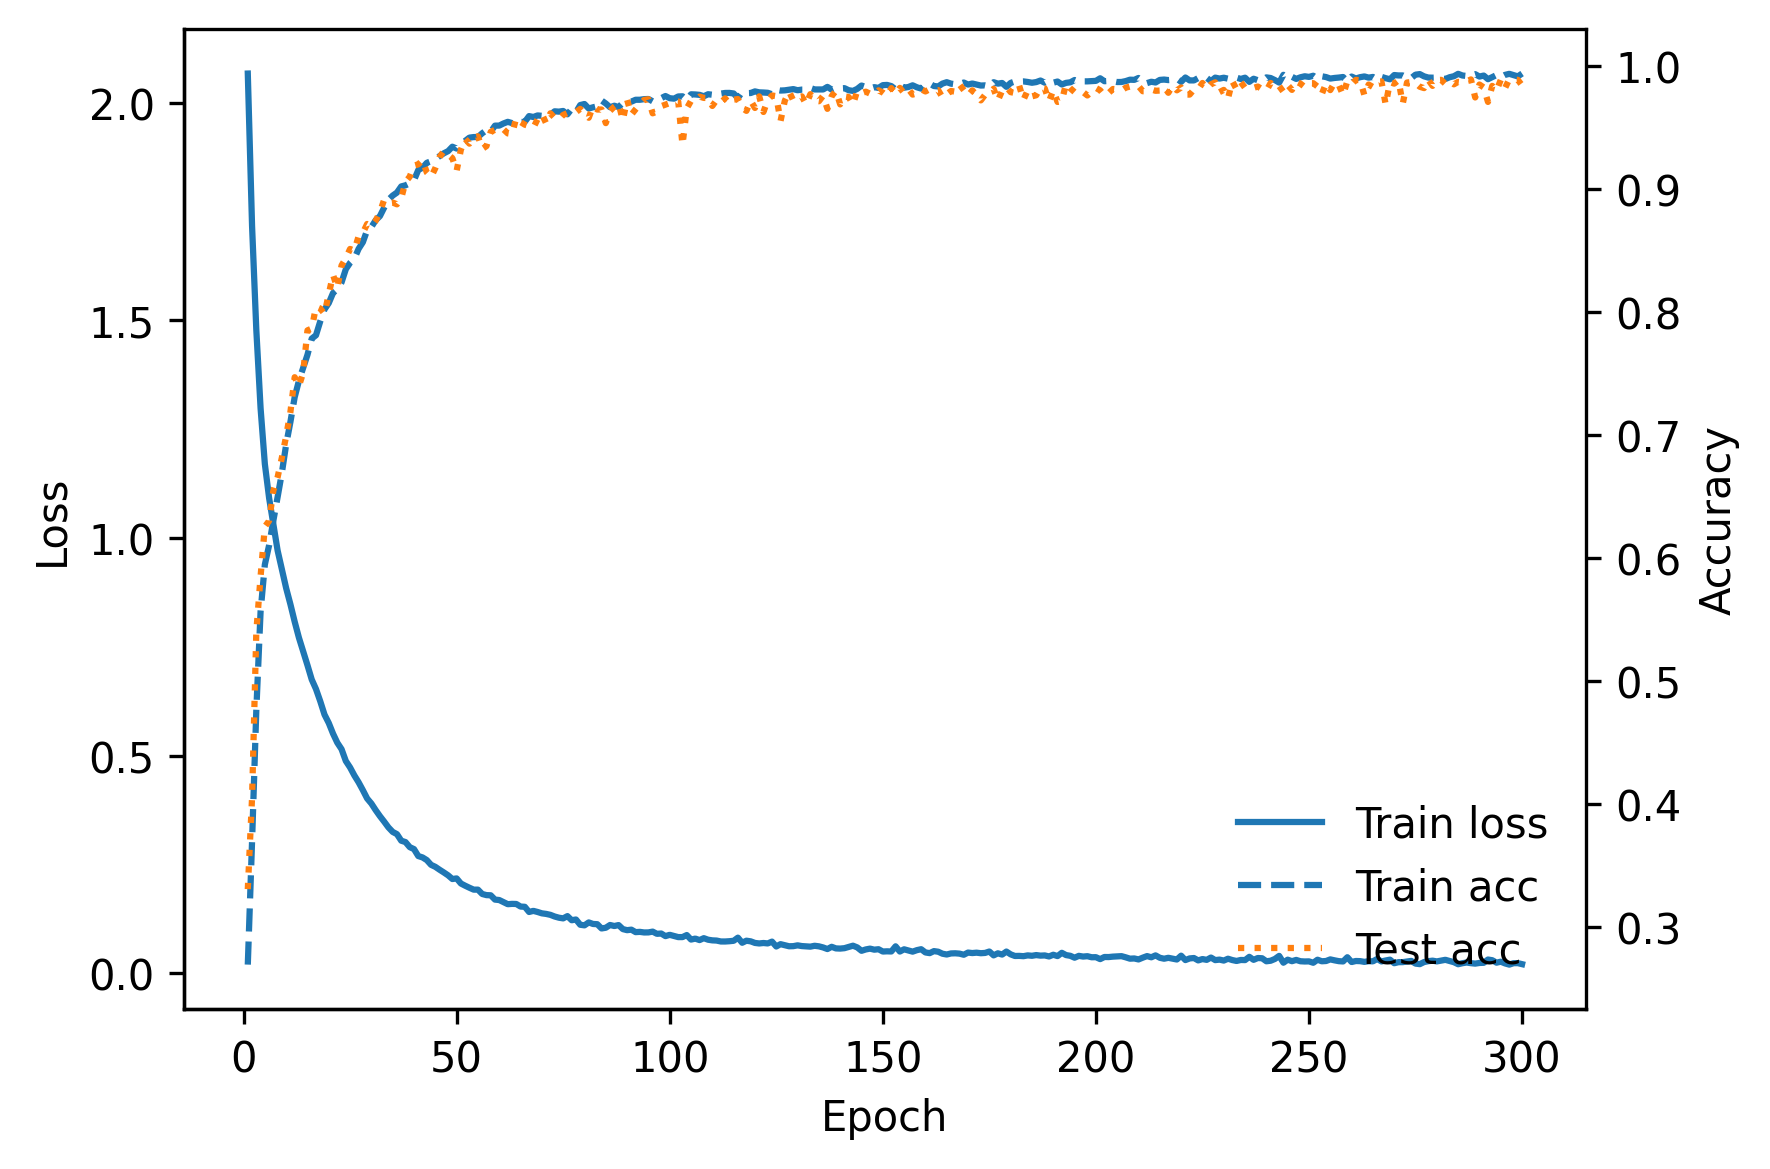

In [13]:
results_all = {}

dbn_res_all, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                    label_col="label",
                    sorce_col='sorce',
                    stratify=False,
                    test_size=0.2,
                    random_state=0,
                    n_pretrain_epochs=50,
                    n_finetune_epochs=300,
                    lr=1e-3,
                    device=None)
results_all.update(dbn_res_all)
dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(RESULT_PATH_FIG, f'{core_name}_dbn_all_feature_training.png'))

训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 21787, 测试集大小: 5796
特征维度: 40
X_train: (21787, 40)
y_train: (21787,)
X_test : (5796, 40)
y_test : (5796,)
DBN input_dim = 40 , n_classes = 11
Pretraining RBM layer 1/2
  Epoch 1/50, recon loss = 0.241426
  Epoch 2/50, recon loss = 0.163218

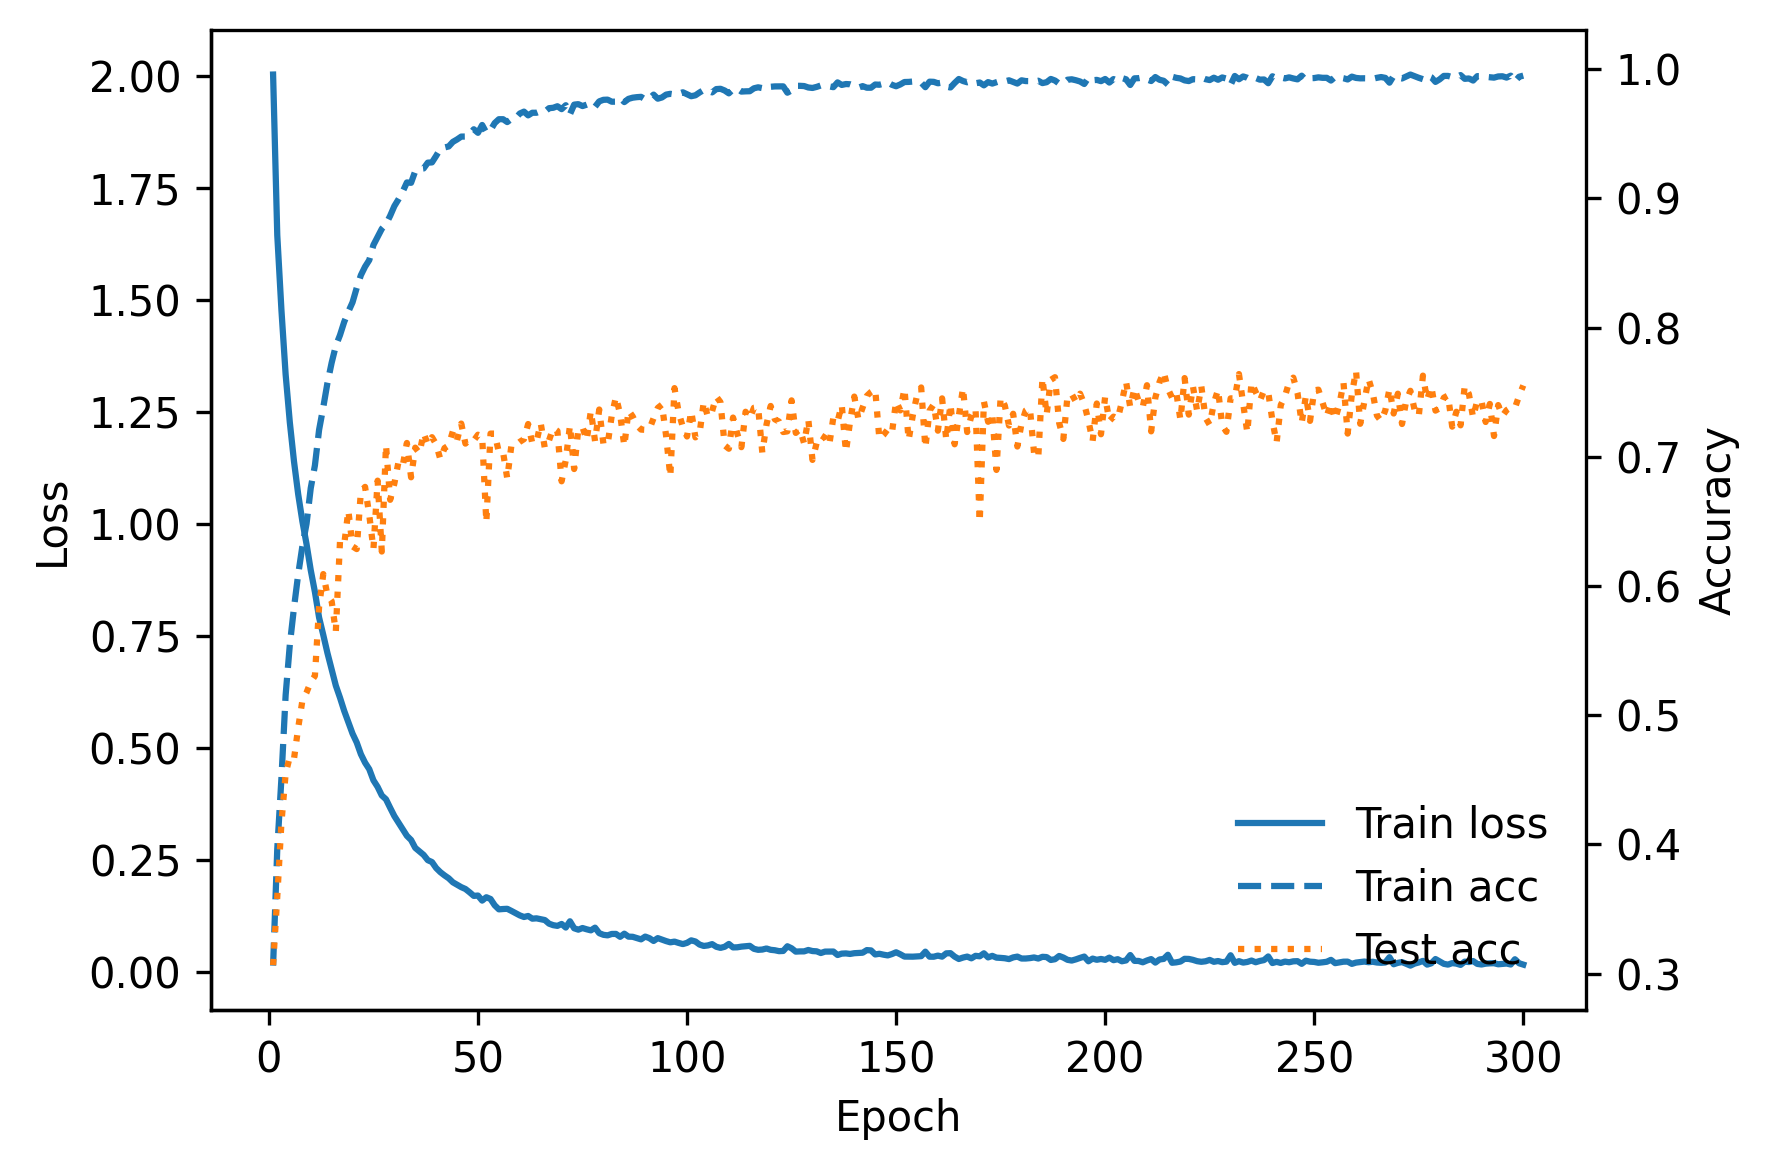

In [15]:
dbn_res_fc_all, (tl, ta, tsa) = dbnm.run_dbn_experiment(feature_df,
                    label_col="label",
                    sorce_col='sorce',
                    stratify=True,
                    test_size=0.2,
                    random_state=0,
                    n_pretrain_epochs=50,
                    n_finetune_epochs=300,
                    lr=1e-3,
                    device=None)
results_all.update(dbn_res_fc_all)
dbnm.plot_dbn_curves(tl, ta, tsa, os.path.join(RESULT_PATH_FIG, f'{core_name}_dbn_all_feature_training.png'))

In [16]:
results_all

{'DBN': {'accuracy': np.float64(0.755175983436853),
  'f1_macro': 0.6525736265863995}}

# 二、尝试进行特征层级的混合模型搭建-

串联的拼贴

In [ ]:
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
#加载手动提取的特征
feature_df = pd.read_csv(feature_csv_path)
#加载原始的信号数据
X, y, label_strs, label_ids, ids = use.load_npz_dataset(r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz')

#提取特征
feature_cols = feature_df.columns.difference(['label','sorce']).tolist()
X_features = feature_df[feature_cols].values
y = feature_df['label'].values 
print(f"X.shape: {X.shape}, X_features.shape: {X_features.shape}, y.shape: {y.shape}")


(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']


正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

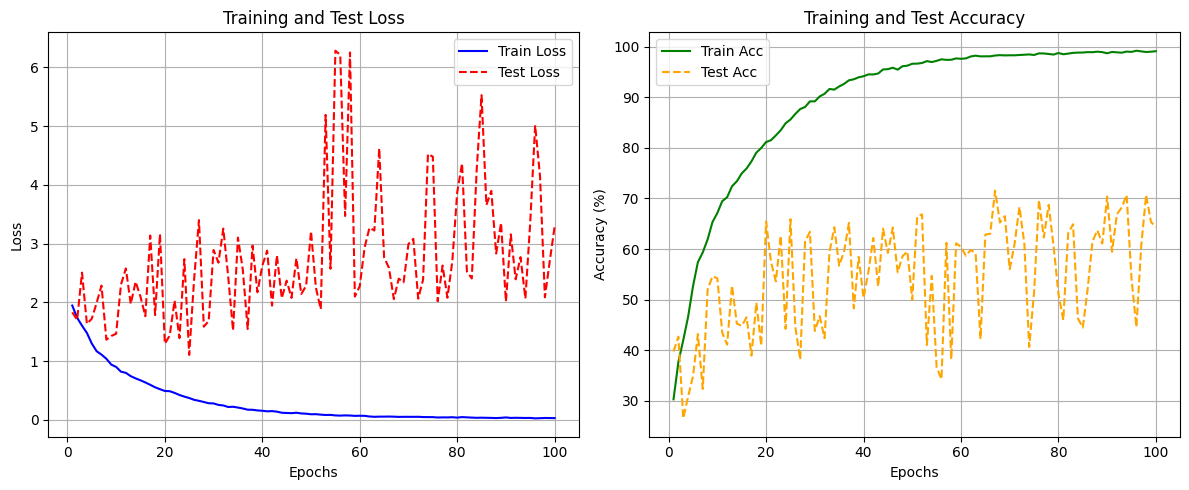

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GroupShuffleSplit # 👈 关键引入
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1. 定义早停机制 (Early Stopping)
# -----------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001):
        """
        Args:
            patience (int): 容忍多少个 epoch loss 不下降
            min_delta (float): 只有 loss 下降超过这个值才被认为是真的改进
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            # Loss 显著下降，保存当前模型为最佳模型
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict()) # 备份参数
            self.counter = 0 # 重置计数器
        else:
            # Loss 没有下降
            self.counter += 1
            print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
# -----------------------------------------------------------
# 1. 模型定义 (保持不变)
# -----------------------------------------------------------
class CNN_LSTM_Model(nn.Module):
    def __init__(self, num_classes):
        super(CNN_LSTM_Model, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4), 
            
            nn.Conv1d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4)
        )
        
        self.lstm = nn.LSTM(
            input_size=64,     
            hidden_size=128,   
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        
        self.fc = nn.Linear(128 * 2, num_classes)
        self.features = None

    def forward(self, x):
        x = x.permute(0, 2, 1)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.permute(0, 2, 1)
        out, (h_n, c_n) = self.lstm(cnn_out)
        final_feature = torch.cat((h_n[-2], h_n[-1]), dim=1)
        self.features = final_feature
        logits = self.fc(final_feature)
        return logits

# -----------------------------------------------------------
# 2. 数据加载与 防泄露划分 (核心修改部分)
# -----------------------------------------------------------
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

# --- 构建 DataLoader ---
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------------------------------------
# 3. 训练循环 (保持不变)
# -----------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM_Model(num_classes=n_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# 初始化早停对象 (容忍度设为 7 轮，如果 7 轮 loss 都不降，就停)
early_stopping = EarlyStopping(patience=50, min_delta=0.01)

# 用于存储曲线数据
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

NUM_EPOCHS = 100 # 设置大一点，反正有早停帮我们把关
print(f"开始训练 (最大 {NUM_EPOCHS} 轮, 启用 Early Stopping)...")

# -----------------------------------------------------------
# 3. 训练主循环
# -----------------------------------------------------------
for epoch in range(NUM_EPOCHS):
    # --- 训练阶段 ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 梯度剪裁
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct / total
    
    # --- 测试/验证阶段 (每轮都做) ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_test_loss = val_running_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * val_correct / val_total
    
    # --- 记录数据 ---
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")
    
    # --- 早停检查 ---
    early_stopping(epoch_train_loss, model)
    
    if early_stopping.early_stop:
        print("🛑 早停触发！停止训练。")
        # 恢复最佳模型参数
        model.load_state_dict(early_stopping.best_model_wts)
        break

# 如果跑完了所有 epoch 且没有早停，也加载最佳模型 (防止最后一轮过拟合)
if not early_stopping.early_stop and early_stopping.best_model_wts:
     model.load_state_dict(early_stopping.best_model_wts)

print("\n训练结束。已加载验证集 Loss 最低的最佳模型参数。")

# -----------------------------------------------------------
# 4. 最终评估与绘图
# -----------------------------------------------------------

# 再次确认最终模型的准确率
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
final_acc = 100 * correct / total
print(f"\n✅ 最佳模型在测试集上的最终准确率: {final_acc:.2f}%")

# --- 绘制曲线 ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# 子图 1: Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='red', linestyle='--')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 子图 2: Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='green')
plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='orange', linestyle='--')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [144]:
def extract_deep_features(model, dataloader, device):
    """
    输入：模型、数据加载器
    输出：提取到的深度特征矩阵 (N, 256), 对应的标签 (N,)
    """
    model.eval() # 切换到评估模式 (关闭 Dropout, 锁定 BN)
    
    feature_list = []
    label_list = []
    
    print(f"正在提取特征 (样本数: {len(dataloader.dataset)})...")
    
    with torch.no_grad(): # 不计算梯度，节省内存，加快速度
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            
            # 1. 前向传播
            # 注意：虽然我们只需要特征，但必须运行 forward 才能更新 model.features
            _ = model(inputs)
            
            # 2. 获取我们在 forward 中存储的 self.features
            # 它的形状应该是 (batch_size, 256)
            batch_features = model.features
            
            # 3. 转回 CPU 并转为 numpy
            feature_list.append(batch_features.cpu().numpy())
            label_list.append(labels.numpy()) # labels 本来就在 CPU 上，如果是 tensor 则需 .cpu()
            
    # 4. 拼接所有 batch
    all_features = np.concatenate(feature_list, axis=0)
    all_labels = np.concatenate(label_list, axis=0)
    
    print(f"✅ 提取完成! 特征维度: {all_features.shape}, 标签维度: {all_labels.shape}")
    return all_features, all_labels

# 1. 提取训练集特征
# 1. 创建推理用的 DataLoader
# 注意：这里必须设置 shuffle=False，保证取出的特征顺序和原始 X_train, y_train 一模一样
train_loader_inference = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader_inference  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# 2. 使用这个新的 Loader 提取特征
print("--- 正在处理训练集 (顺序模式) ---")
train_deep_features, train_labels_check = extract_deep_features(model, train_loader_inference, device)

print("\n--- 正在处理测试集 (顺序模式) ---")
test_deep_features, test_labels_check = extract_deep_features(model, test_loader_inference, device)

# 3. 再次验证顺序
# 这次应该能完美通过了
print("\n正在验证标签一致性...")
assert np.array_equal(train_labels_check, y_train.numpy()), "❌ 错误：训练集标签依然对不上！"
assert np.array_equal(test_labels_check, y_test.numpy()), "❌ 错误：测试集标签依然对不上！"

print("✅ 验证通过！深度特征与原始数据顺序完全一致。")

# 3. 保存特征 (强烈建议保存，方便下一步融合)
save_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\deep_features_cnn_lstm.npz'
np.savez(save_path, 
         X_train_deep=train_deep_features, 
         y_train=train_labels_check,
         X_test_deep=test_deep_features, 
         y_test=test_labels_check)

print(f"深度特征已保存至: {save_path}")

--- 正在处理训练集 (顺序模式) ---
正在提取特征 (样本数: 22080)...
✅ 提取完成! 特征维度: (22080, 256), 标签维度: (22080,)

--- 正在处理测试集 (顺序模式) ---
正在提取特征 (样本数: 5503)...
✅ 提取完成! 特征维度: (5503, 256), 标签维度: (5503,)

正在验证标签一致性...
✅ 验证通过！深度特征与原始数据顺序完全一致。
深度特征已保存至: E:\故障诊断2\实验整理\dataset\processed\npz\deep_features_cnn_lstm.npz


In [146]:
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
#加载手动提取的特征
feature_df = pd.read_csv(feature_csv_path)
feature_df

,time_mean,time_std,time_rms,time_pp,time_max,time_min,time_skew,time_kurt,time_crest_factor,time_shape_factor,...,envspec_bandwidth,envspec_peak_freq,envspec_peak_amp,envspec_entropy,stft_band0_mean_energy_0_1000Hz,stft_band1_mean_energy_1000_3000Hz,stft_band2_mean_energy_3000_6000Hz,spectral_entropy,label,sorce
0,-0.000165,0.086479,0.086479,0.577782,0.300134,-0.277648,0.053999,0.150479,3.470591,1.271210,...,1462.118891,23.437500,14.623088,6.519562,0.000045,0.000030,0.000047,6.331675,0,X282
1,0.000082,0.096349,0.096349,0.811039,0.414651,-0.396388,0.035188,0.749227,4.303629,1.290682,...,1454.695114,5.859375,23.874775,6.459174,0.000041,0.000031,0.000067,6.094400,0,X282
2,-0.000040,0.097438,0.097438,0.811039,0.414651,-0.396388,0.015865,0.706248,4.255531,1.286064,...,1425.222393,17.578125,26.100977,6.435100,0.000035,0.000033,0.000069,6.097412,0,X282
3,-0.000382,0.090007,0.090008,0.771567,0.413027,-0.358540,0.059224,0.486491,4.588763,1.274769,...,1440.019096,11.718750,20.053417,6.473177,0.000038,0.000028,0.000061,6.054425,0,X282
4,-0.000145,0.089612,0.089612,0.771567,0.413027,-0.358540,0.032676,0.294488,4.609030,1.269348,...,1441.107556,11.718750,19.294323,6.485554,0.000041,0.000028,0.000059,6.114111,0,X282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27578,0.000962,0.129099,0.129103,1.111952,0.585169,-0.526783,0.023466,1.834905,4.532589,1.345986,...,1324.638174,29.296875,56.981052,6.105928,0.000371,0.000077,0.000004,5.390064,10,X249
27579,0.000098,0.132103,0.132103,1.111952,0.585169,-0.526783,0.023187,1.724031,4.429638,1.344116,...,1328.268430,29.296875,62.895275,6.078090,0.000391,0.000085,0.000004,5.313682,10,X249
27580,-0.000177,0.133435,0.133435,1.226174,0.626301,-0.599872,0.045543,1.973442,4.693666,1.365740,...,1315.327222,46.875000,64.794440,6.094894,0.000387,0.000088,0.000004,5.392142,10,X249
27581,0.000399,0.133948,0.133949,1.226174,0.626301,-0.599872,0.054008,1.955133,4.675669,1.364067,...,1319.179261,29.296875,59.339523,6.102350,0.000403,0.000084,0.000003,5.245969,10,X249


In [45]:
#复活深度特征
deep_features_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\deep_features_cnn_lstm.npz'
deep_features_data = np.load(deep_features_path)
X_train_deep = deep_features_data['X_train_deep']
y_train = deep_features_data['y_train']
X_test_deep = deep_features_data['X_test_deep']
y_test = deep_features_data['y_test']

# 加载手动提取的特征（从CSV文件中）
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

X_train_manual = feature_df.iloc[:22080, :-2].values  # 训练集特征
X_test_manual = feature_df.iloc[22080:, :-2].values  # 测试集特征


# 合并深度特征和手工特征
X_train_combined = np.hstack((X_train_deep, X_train_manual))  # 训练集合并
X_test_combined = np.hstack((X_test_deep, X_test_manual))  # 测试集合并


# 合并标签列
X_train_combined_df = pd.DataFrame(X_train_combined)
X_train_combined_df['label'] = y_train  # 添加训练集标签
X_train_combined_df['sorce'] = feature_df.iloc[:22080, :]['sorce']  # 添加训练集标签

X_test_combined_df = pd.DataFrame(X_test_combined)
X_test_combined_df['label'] = y_test  # 添加测试集标签
X_test_combined_df['sorce'] = feature_df.iloc[22080:,:]['sorce'] .values  # 添加训练集标签

# 输出合并后的训练集和测试集特征的形状，检查是否合并成功
print(f"训练集合并后特征维度: {X_train_combined_df.shape}")
print(f"测试集合并后特征维度: {X_test_combined_df.shape}")

X_train_combined_df.to_csv('E:\故障诊断2\实验整理\dataset\processed\csv\combined_train_features_with_labels.csv', index=False)


训练集合并后特征维度: (22080, 298)
测试集合并后特征维度: (5503, 298)


In [46]:
combined_df_all = pd.concat([X_train_combined_df,X_test_combined_df],axis = 0)

In [48]:
#得到了一份新的数据集，尝试训练模型。
from utils import classical_ml as cm

results_env = cm.run_baseline_experiments(
    combined_df_all, 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=False  # 如果需要根据 sorce 列分层划分
)


训练集大小: 22066, 测试集大小: 5517
特征维度: 296

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.9003, F1_macro: 0.9070
分类报告:
              precision    recall  f1-score   support

           0     0.7855    0.8383    0.8111       402
           1     0.8558    0.8440    0.8499       436
           2     0.7678    0.7448    0.7561       435
           3     1.0000    1.0000    1.0000        83
           4     0.9524    0.9545    0.9535       440
           5     0.8884    0.8945    0.8914       436
           6     0.9551    0.9634    0.9592       464
           7     1.0000    1.0000    1.0000        92
           8     0.9134    0.9189    0.9162      1332
           9     0.9105    0.8803    0.8951       543
          10     0.9481    0.9415    0.9448       854

    accuracy                         0.9003      5517
   macro avg     0.9070    0.9073    0.9070      5517
weighted avg     0.9005    0.9003    0.9003      5517

混淆矩阵:
[[ 337   14   20    0    5    7    1    0    7   10    1]
 [  17  368   24    0    0    7    4    0    7    6    3]
 [  36   19  32

Exception in thread Thread-295 (_readerthread):
Traceback (most recent call last):
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "d:\anaconda\envs\pikaqiu\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\anaconda\envs\pikaqiu\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anaconda\envs\pikaqiu\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


KNN_5 - Accuracy: 0.9331, F1_macro: 0.9384
分类报告:
              precision    recall  f1-score   support

           0     0.8168    0.9428    0.8753       402
           1     0.9361    0.8394    0.8851       436
           2     0.9080    0.8391    0.8722       435
           3     1.0000    1.0000    1.0000        83
           4     0.9660    0.9682    0.9671       440
           5     0.9466    0.9358    0.9412       436
           6     0.9696    0.9612    0.9654       464
           7     1.0000    1.0000    1.0000        92
           8     0.9423    0.9437    0.9430      1332
           9     0.9247    0.9042    0.9143       543
          10     0.9403    0.9778    0.9587       854

    accuracy                         0.9331      5517
   macro avg     0.9409    0.9375    0.9384      5517
weighted avg     0.9343    0.9331    0.9330      5517

混淆矩阵:
[[ 379    7    5    0    2    3    0    0    1    4    1]
 [  22  366   14    0    0    4    4    0   14   10    2]
 [  31    4  365

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Accuracy: 0.9955, F1_macro: 0.9952
分类报告:
              precision    recall  f1-score   support

           0     0.9803    0.9900    0.9851       402
           1     0.9862    0.9862    0.9862       436
           2     0.9954    0.9908    0.9931       435
           3     1.0000    1.0000    1.0000        83
           4     1.0000    1.0000    1.0000       440
           5     0.9931    0.9931    0.9931       436
           6     0.9978    0.9935    0.9957       464
           7     1.0000    1.0000    1.0000        92
           8     0.9978    1.0000    0.9989      1332
           9     1.0000    0.9945    0.9972       543
          10     0.9977    0.9977    0.9977       854

    accuracy                         0.9955      5517
   macro avg     0.9953    0.9951    0.9952      5517
weighted avg     0.9955    0.9955    0.9955      5517

混淆矩阵:
[[ 398    3    0    0    0    1    0    0    0    0    0]
 [   3  430    1    0    0    1    0    0    0    0    1]
 [   0    3  

In [49]:
results_env_fc = cm.run_baseline_experiments(
   combined_df_all, 
    label_col="label", 
    sorce_col="sorce",  # 新加入的字段
    stratify=True  # 如果需要根据 sorce 列分层划分
)


不同来源的训练和测试
训练集样本： ['X209' 'X285' 'X058' 'X199' 'X059' 'X288' 'X236' 'X234' 'X133' 'X108'
 'X145' 'X159' 'X212' 'X222' 'X297' 'X276' 'X050' 'X158' 'X105' 'X259'
 'X249' 'X283' 'X130' 'X316' 'X312' 'X286' 'X281' 'X275' 'X311' 'X310'
 'X287' 'X261' 'X223' 'X282' 'X298' 'X313' 'X224' 'X186' 'X293' 'X299'
 'X273' 'X188' 'X292' 'X305' 'X132' 'X048' 'X197' 'X160' 'X306' 'X260'
 'X280' 'X057' 'X277' 'X315' 'X185' 'X247' 'X248' 'X210' 'X270' 'X146'
 'X056' 'X131' 'X295' 'X301' 'X198' 'X119' 'X309' 'X170' 'X049' 'X278'
 'X258' 'X156' 'X211' 'X237' 'X300' 'X271' 'X200' 'X291' 'X246' 'X172'
 'X169' 'X120' 'X318']
测试集样本： ['X296' 'X106' 'X284' 'X107' 'X235' 'X121' 'X274' 'X147' 'X225' 'X118'
 'X171' 'X144' 'X187' 'X279' 'X289' 'X302' 'X272' 'X294' 'X307' 'X290'
 'X317']
训练集大小: 21787, 测试集大小: 5796
特征维度: 296

训练模型: LogReg


d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg - Accuracy: 0.6142, F1_macro: 0.6274
分类报告:
              precision    recall  f1-score   support

           0     0.3319    0.8333    0.4747       276
           1     0.0792    0.1927    0.1123       109
           2     0.7918    0.2575    0.3886      1196
           3     0.7653    1.0000    0.8671        75
           4     0.7669    0.9239    0.8381       552
           5     0.5108    0.3587    0.4215       460
           6     0.8326    0.7301    0.7780       552
           7     1.0000    1.0000    1.0000        92
           8     0.5704    0.7781    0.6582      1104
           9     0.6833    0.5966    0.6370       828
          10     0.7222    0.7301    0.7261       552

    accuracy                         0.6142      5796
   macro avg     0.6413    0.6728    0.6274      5796
weighted avg     0.6744    0.6142    0.6049      5796

混淆矩阵:
[[230   1  12   0  12   6   5   0   4   4   2]
 [  0  21  17   0   0   0   0   0  51  11   9]
 [214 211 308   0  61  20  58   0 208

d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Accuracy: 0.6080, F1_macro: 0.6430
分类报告:
              precision    recall  f1-score   support

           0     0.3435    0.8949    0.4965       276
           1     0.2095    0.8532    0.3363       109
           2     0.7119    0.1405    0.2346      1196
           3     0.7979    1.0000    0.8876        75
           4     0.7378    0.9022    0.8117       552
           5     0.6317    0.4587    0.5315       460
           6     0.8101    0.8424    0.8259       552
           7     1.0000    1.0000    1.0000        92
           8     0.5701    0.7554    0.6498      1104
           9     0.8592    0.6413    0.7344       828
          10     0.5667    0.5616    0.5641       552

    accuracy                         0.6080      5796
   macro avg     0.6580    0.7318    0.6430      5796
weighted avg     0.6762    0.6080    0.5863      5796

混淆矩阵:
[[247   0   0   0  16   6   5   0   2   0   0]
 [  0  93   7   0   0   1   0   0   0   0   8]
 [271 330 168   0  22  58  93   0 1

In [50]:
cm.results_to_dataframe(results_env)

,accuracy,f1_macro
model,,
LightGBM,0.995469,0.995185
XGBoost,0.991843,0.991770
CatBoost,0.975893,0.976989
RandomForest,0.971361,0.973359
ExtraTrees,0.968461,0.970453
SVM_RBF,0.967917,0.970002
GradBoost,0.965924,0.967909
KNN_5,0.933116,0.938382
LinearSVM,0.900489,0.902632


In [52]:
results_sum = {
    "env_feature":results_env,
    "env_feature-fc":results_env_fc,
}

df_env_scores = cm.results_env_to_dataframe(results_sum)
df_env_scores

accuracy  f1_macro
env            model                           
env_feature    LightGBM      0.995469  0.995185
               XGBoost       0.991843  0.991770
               CatBoost      0.975893  0.976989
               RandomForest  0.971361  0.973359
               ExtraTrees    0.968461  0.970453
               SVM_RBF       0.967917  0.970002
               GradBoost     0.965924  0.967909
               KNN_5         0.933116  0.938382
               LinearSVM     0.900489  0.902632
               LogReg        0.900308  0.907024
               Ridge         0.841037  0.854713
               NaiveBayes    0.555918  0.633333
env_feature-fc SVM_RBF       0.644755  0.678615
               KNN_5         0.642167  0.667403
               LogReg        0.614217  0.627423
               XGBoost       0.609386  0.647864
               ExtraTrees    0.609041  0.634413
               LightGBM      0.608006  0.642961
               CatBoost      0.603347  0.649990
               LinearSVM     0.602484  0.565847
               Ridge         0.593858  0.636999
               RandomForest  0.588337  0.626994
               GradBoost     0.584369  0.618359
               NaiveBayes    0.394582  0.491626

In [4]:
import copy # 用于 EarlyStopping

# 三、混合特征建模-串联方式1，端到端的融合，建模过程中融入手动特征

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GroupShuffleSplit # 👈 关键引入
import numpy as np
import matplotlib.pyplot as plt
# 🔥 补充导入缺失的库
import torch.nn.functional as F  
import pandas as pd 
import copy # 用于 EarlyStopping
from sklearn.model_selection import GroupShuffleSplit # 👈 关键引入

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

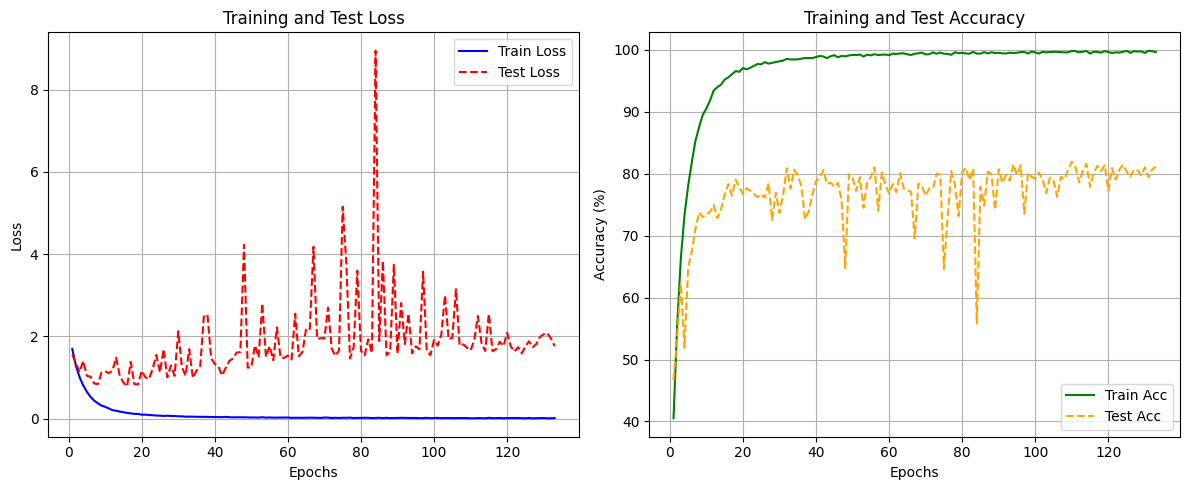

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GroupShuffleSplit # 👈 关键引入
import numpy as np
import matplotlib.pyplot as plt
# 🔥 补充导入缺失的库
import torch.nn.functional as F  
import pandas as pd 
import copy # 用于 EarlyStopping


class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001):
        """
        Args:
            patience (int): 容忍多少个 epoch loss 不下降
            min_delta (float): 只有 loss 下降超过这个值才被认为是真的改进
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            # Loss 显著下降，保存当前模型为最佳模型
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict()) # 备份参数
            self.counter = 0 # 重置计数器
        else:
            # Loss 没有下降
            self.counter += 1
            print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
# 特征注意力融合模块
# -----------------------------------------------------------
class FeatureAttention(nn.Module):
    """
    用于融合深度特征和手动特征，并进行加权分配的注意力模块。
    这里实现了一个简单的通道注意力机制，用于学习特征向量中每个元素的权重。
    """
    def __init__(self, feature_dim):
        super(FeatureAttention, self).__init__()
        # 降维层 (用于计算权重，通常使用 ReLU 或 Sigmoid 激活)
        self.attn_fc1 = nn.Linear(feature_dim, feature_dim // 4) 
        # 升维层 (输出的维度与特征维度相同)
        self.attn_fc2 = nn.Linear(feature_dim // 4, feature_dim)
        
    def forward(self, x):
        # x 是融合后的特征 (Batch_size, Fusion_Dim)
        
        # 1. 计算注意力分数
        # 使用 ReLU 来捕捉非线性关系
        weights = F.relu(self.attn_fc1(x))
        # 使用 Sigmoid 将权重限制在 [0, 1] 之间
        weights = torch.sigmoid(self.attn_fc2(weights))
        
        # 2. 特征加权
        # 将原始特征与学到的权重相乘
        weighted_feature = x * weights
        
        return weighted_feature


# 2. 模型定义 (包含特征融合和注意力机制)
# -----------------------------------------------------------
class CNN_LSTM_Fusion_Model(nn.Module):
    def __init__(self, manual_feature_dim, num_classes):
        super(CNN_LSTM_Fusion_Model, self).__init__()
        
        # 1. 深度特征提取部分 (与原模型保持一致)
        # CNN部分
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4), 
            nn.Conv1d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4)
        )
        
        # BiLSTM部分
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        # 深度特征维度： 128 (hidden_size) * 2 (bidirectional) = 256
        self.deep_feature_dim = 128 * 2
        
        # 2. 融合层定义
        # 总特征维度 = 深度特征维度 + 手动特征维度
        self.fusion_feature_dim = self.deep_feature_dim + manual_feature_dim
        
        # 3. 特征注意力机制
        self.attention_block = FeatureAttention(self.fusion_feature_dim)
        
        # 4. 最终分类器 (采用一个简单的MLP结构)
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_feature_dim, 256), # 降维到 256
            nn.ReLU(),
            nn.Dropout(0.5), # 引入 Dropout 防止过拟合
            nn.Linear(256, num_classes)
        )

    def forward(self, x_signal, x_manual):
        # x_signal: 振动信号 (Batch, Length, 1)
        # x_manual: 手动特征 (Batch, Manual_Feature_Dim)
        
        # --- 1. 提取深度特征 ---
        x = x_signal.permute(0, 2, 1) # (B, 1, L)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.permute(0, 2, 1) # (B, Time_Steps, Channels)
        
        # 提取最终的深度特征 (使用BiLSTM的最后一个时间步的隐藏状态)
        _, (h_n, c_n) = self.lstm(cnn_out)
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) # (B, 256)
        
        # --- 2. 特征融合 (拼接) ---
        # 确保 x_manual 也是 Tensor 并且在正确的设备上
        fused_feature = torch.cat((deep_feature, x_manual), dim=1) # (B, 256 + Manual_Dim)
        
        # --- 3. 注意力加权 ---
        weighted_feature = self.attention_block(fused_feature)
        
        # --- 4. 最终分类 ---
        logits = self.fc_classifier(weighted_feature)
        return logits


# 数据加载与 防泄露划分 (核心修改部分)
# -----------------------------------------------------------
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)



#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)
#------------------------------------------


# --- 构建 DataLoader ---
batch_size = 128
train_dataset = TensorDataset(X_train, X_manual_train, y_train)
test_dataset = TensorDataset(X_test, X_manual_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------------------------------------
# 3. 训练循环 (保持不变)
# -----------------------------------------------------------
manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ⚠️ 初始化新模型
model = CNN_LSTM_Fusion_Model(
    manual_feature_dim=manual_feature_dim, 
    num_classes=n_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# 初始化早停对象 (容忍度设为 7 轮，如果 7 轮 loss 都不降，就停)
early_stopping = EarlyStopping(patience=50, min_delta=0.01)

# 用于存储曲线数据
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

NUM_EPOCHS = 200 # 设置大一点，反正有早停帮我们把关
print(f"开始训练 (最大 {NUM_EPOCHS} 轮, 启用 Early Stopping)...")

# -----------------------------------------------------------
# 3. 训练主循环
# -----------------------------------------------------------
for epoch in range(NUM_EPOCHS):
    # --- 训练阶段 ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs_signal, inputs_manual, labels in train_loader:
        # 将三个变量都移动到设备上
        inputs_signal = inputs_signal.to(device)
        inputs_manual = inputs_manual.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # ⚠️ 关键修改：模型需要两个输入
        outputs = model(inputs_signal, inputs_manual) 
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 梯度剪裁
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs_signal.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct / total
    
    # --- 测试/验证阶段 (每轮都做) ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs_signal, inputs_manual, labels in test_loader:
            # 将三个变量都移动到设备上
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            outputs = model(inputs_signal, inputs_manual)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs_signal.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_test_loss = val_running_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * val_correct / val_total
    
    # --- 记录数据 ---
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")
    
    # --- 早停检查 ---
    early_stopping(epoch_train_loss, model)
    
    if early_stopping.early_stop:
        print("🛑 早停触发！停止训练。")
        # 恢复最佳模型参数
        model.load_state_dict(early_stopping.best_model_wts)
        break

# 如果跑完了所有 epoch 且没有早停，也加载最佳模型 (防止最后一轮过拟合)
if not early_stopping.early_stop and early_stopping.best_model_wts:
     model.load_state_dict(early_stopping.best_model_wts)

print("\n训练结束。已加载验证集 Loss 最低的最佳模型参数。")

# -----------------------------------------------------------
# 4. 最终评估与绘图
# -----------------------------------------------------------

# 再次确认最终模型的准确率
model.eval()
correct = 0
total = 0
with torch.no_grad():
    # 🔥 关键修正：解包出两个输入特征
    for inputs_signal, inputs_manual, labels in test_loader: 
        # 将三个变量都移动到设备上
        inputs_signal = inputs_signal.to(device)
        inputs_manual = inputs_manual.to(device)
        labels = labels.to(device)
        
        # 🔥 关键修正：传入两个特征
        outputs = model(inputs_signal, inputs_manual) 
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
final_acc = 100 * correct / total
print(f"\n✅ 最佳模型在测试集上的最终准确率: {final_acc:.2f}%")

# --- 绘制曲线 ---
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# 子图 1: Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='red', linestyle='--')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 子图 2: Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='green')
plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='orange', linestyle='--')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 四。参数巡游计划

In [3]:
from tqdm import tqdm
# -----------------------------------------------------------
# 3. 定义 Optuna Objective 函数
# -----------------------------------------------------------
def objective(trial, X_train, X_manual_train, y_train, X_test, X_manual_test, y_test, n_classes, manual_feature_dim, device):
    
    # 1. 定义超参数搜索空间
    
    # 学习率 (log-uniform search)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    # Batch Size (discrete choice)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    # Dropout Rate
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.6)
    # LSTM Hidden Size (must be an integer)
    lstm_hidden_size = trial.suggest_categorical("lstm_hidden_size", [64, 128, 256])
    # Optimizer Choice
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    # 2. 模型和数据加载器实例化
    
    # 构建 DataLoader
    train_dataset = TensorDataset(X_train, X_manual_train, y_train)
    test_dataset = TensorDataset(X_test, X_manual_test, y_test)
    # train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 实例化模型 (注意：模型结构需要适应新的超参数，后面会修改)
    model = CNN_LSTM_Fusion_Model(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=lstm_hidden_size, # 传入新的参数
        dropout_rate=dropout_rate         # 传入新的参数
    ).to(device)

    # 实例化优化器
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=20, min_delta=0.01) # 调参时可减少耐心值

    # 3. 训练循环
    for epoch in range(100): 
        model.train()
        running_loss = 0.0
        
        for inputs_signal, inputs_manual, labels in train_loader:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # 使用 loss.item() 避免显存累积
            running_loss += loss.item() * inputs_signal.size(0)

        # --- 评估 ---
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_acc = val_correct / val_total

        # --- 进度监控 (减少打印) ---
        # 只有在特定的 epoch 才打印，或者 Trial 的最后
        if (epoch + 1) % 10 == 0:
            print(f"Trial {trial.number}, Epoch {epoch+1} -> Test Acc: {epoch_test_acc:.4f}")

        # --- Optuna 剪枝 ---
        trial.report(epoch_test_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return epoch_test_acc
        

In [4]:
import optuna
from optuna.trial import TrialState # 用于早停判断
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001):
        """
        Args:
            patience (int): 容忍多少个 epoch loss 不下降
            min_delta (float): 只有 loss 下降超过这个值才被认为是真的改进
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            # Loss 显著下降，保存当前模型为最佳模型
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict()) # 备份参数
            self.counter = 0 # 重置计数器
        else:
            # Loss 没有下降
            self.counter += 1
            print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
# 特征注意力融合模块
class FeatureAttention(nn.Module):
    """
    用于融合深度特征和手动特征，并进行加权分配的注意力模块。
    这里实现了一个简单的通道注意力机制，用于学习特征向量中每个元素的权重。
    """
    def __init__(self, feature_dim):
        super(FeatureAttention, self).__init__()
        # 降维层 (用于计算权重，通常使用 ReLU 或 Sigmoid 激活)
        self.attn_fc1 = nn.Linear(feature_dim, feature_dim // 4) 
        # 升维层 (输出的维度与特征维度相同)
        self.attn_fc2 = nn.Linear(feature_dim // 4, feature_dim)
        
    def forward(self, x):
        # x 是融合后的特征 (Batch_size, Fusion_Dim)
        
        # 1. 计算注意力分数
        # 使用 ReLU 来捕捉非线性关系
        weights = F.relu(self.attn_fc1(x))
        # 使用 Sigmoid 将权重限制在 [0, 1] 之间
        weights = torch.sigmoid(self.attn_fc2(weights))
        
        # 2. 特征加权
        # 将原始特征与学到的权重相乘
        weighted_feature = x * weights
        
        return weighted_feature
class CNN_LSTM_Fusion_Model(nn.Module):

    def __init__(self, manual_feature_dim, num_classes, lstm_hidden_size, dropout_rate): 
        super(CNN_LSTM_Fusion_Model, self).__init__()
        
        # 1. 深度特征提取部分 (与原模型保持一致)
        # CNN部分
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4), 
            nn.Conv1d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4)
        )
        
        
        
        # BiLSTM部分 - 使用可变 hidden_size
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden_size, # 🔥 使用传入的 hidden_size
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        # 深度特征维度： hidden_size * 2
        self.deep_feature_dim = lstm_hidden_size * 2
        
        # 2. 融合层定义 - 适应可变维度
        self.fusion_feature_dim = self.deep_feature_dim + manual_feature_dim
        
        # 3. 特征注意力机制 - 适应可变维度
        self.attention_block = FeatureAttention(self.fusion_feature_dim)
        
        # 4. 最终分类器 - 适应可变维度和可变 Dropout
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_feature_dim, 256), 
            nn.ReLU(),
            nn.Dropout(dropout_rate), # 🔥 使用传入的 dropout_rate
            nn.Linear(256, num_classes)
        )

    def forward(self, x_signal, x_manual):
        # x_signal: 振动信号 (Batch, Length, 1)
        # x_manual: 手动特征 (Batch, Manual_Feature_Dim)
        
        # --- 1. 提取深度特征 ---
        x = x_signal.permute(0, 2, 1) # (B, 1, L)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.permute(0, 2, 1) # (B, Time_Steps, Channels)
        
        # 提取最终的深度特征 (使用BiLSTM的最后一个时间步的隐藏状态)
        _, (h_n, c_n) = self.lstm(cnn_out)
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) # (B, 256)
        
        # --- 2. 特征融合 (拼接) ---
        # 确保 x_manual 也是 Tensor 并且在正确的设备上
        fused_feature = torch.cat((deep_feature, x_manual), dim=1) # (B, 256 + Manual_Dim)
        
        # --- 3. 注意力加权 ---
        weighted_feature = self.attention_block(fused_feature)
        
        # --- 4. 最终分类 ---
        logits = self.fc_classifier(weighted_feature)
        return logits


d:\anaconda\envs\pikaqiu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)


#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)
#------------------------------------------


# --- 构建 DataLoader ---
batch_size = 128
train_dataset = TensorDataset(X_train, X_manual_train, y_train)
test_dataset = TensorDataset(X_test, X_manual_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------
# 4. Optuna 寻优启动
# -----------------------------------------------------------
# 定义数据库文件的名字 (会在当前目录下生成一个 .db 文件)
db_name = r"E:\故障诊断2\实验整理\code\DBN_FD\optuna_bearing_experiment.db"
storage_name = f"sqlite:///{db_name}"

print(f"🚀 正在连接数据库: {db_name}")
print("✅ 即使程序中断，再次运行代码时将自动加载此数据库，进度不会丢失！")

pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=100, reduction_factor=3)
sampler = optuna.samplers.TPESampler(seed=42)

# 🔥 load_if_exists=True 允许我们加载之前的进度
study = optuna.create_study(
    direction="maximize", 
    sampler=sampler, 
    pruner=pruner,
    study_name="CNN_LSTM_Fusion_HPO_v1", # 给你的实验起个固定的名字
    storage=storage_name,                # 指定数据库路径
    load_if_exists=True                  # 如果数据库存在，就加载以前的进度！
)

print("🚀 开始 Optuna 超参数优化...")
optimization_kwargs = {
    "X_train": X_train, 
    "X_manual_train": X_manual_train, 
    "y_train": y_train,
    "X_test": X_test, 
    "X_manual_test": X_manual_test, 
    "y_test": y_test,
    "n_classes": n_classes,
    "manual_feature_dim": manual_feature_dim,
    "device": device
}

# 设定总共想跑多少次 Trial (比如 50)
# 如果数据库里已经有了 10 次，它会从第 11 次开始跑，直到凑够 50 次
study.optimize(
    lambda trial: objective(trial, **optimization_kwargs), 
    n_trials=50 
)

print("\n🎉 寻优完成！")
print(f"最佳准确率: {study.best_value:.4f}")
print("最佳超参数:", study.best_params)

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

[I 2025-12-07 21:21:26,290] A new study created in RDB with name: CNN_LSTM_Fusion_HPO_v1


🚀 开始 Optuna 超参数优化...
Trial 0, Epoch 10 -> Test Acc: 0.5388
Trial 0, Epoch 20 -> Test Acc: 0.5800
Trial 0, Epoch 30 -> Test Acc: 0.6126
Trial 0, Epoch 40 -> Test Acc: 0.6731
Trial 0, Epoch 50 -> Test Acc: 0.7276
Trial 0, Epoch 60 -> Test Acc: 0.7242
Trial 0, Epoch 70 -> Test Acc: 0.7434
Trial 0, Epoch 80 -> Test Acc: 0.7572
Trial 0, Epoch 90 -> Test Acc: 0.7888


[I 2025-12-07 21:41:43,071] Trial 0 finished with value: 0.7621297474105033 and parameters: {'lr': 5.6115164153345e-05, 'batch_size': 64, 'dropout_rate': 0.34680559213273093, 'lstm_hidden_size': 256, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.7621297474105033.


Trial 0, Epoch 100 -> Test Acc: 0.7621
Trial 1, Epoch 10 -> Test Acc: 0.4025
Trial 1, Epoch 20 -> Test Acc: 0.4774
Trial 1, Epoch 30 -> Test Acc: 0.5048
Trial 1, Epoch 40 -> Test Acc: 0.5266
Trial 1, Epoch 50 -> Test Acc: 0.5246
Trial 1, Epoch 60 -> Test Acc: 0.5384
Trial 1, Epoch 70 -> Test Acc: 0.5541
Trial 1, Epoch 80 -> Test Acc: 0.5532
Trial 1, Epoch 90 -> Test Acc: 0.5860


...

Trial 48, Epoch 10 -> Test Acc: 0.7107
Trial 48, Epoch 20 -> Test Acc: 0.7472
Trial 48, Epoch 30 -> Test Acc: 0.7976
Trial 48, Epoch 40 -> Test Acc: 0.7874
Trial 48, Epoch 50 -> Test Acc: 0.8010
Trial 48, Epoch 60 -> Test Acc: 0.8039
Trial 48, Epoch 70 -> Test Acc: 0.8090
Trial 48, Epoch 80 -> Test Acc: 0.8037
Trial 48, Epoch 90 -> Test Acc: 0.8059


[I 2025-12-07 23:52:44,359] Trial 48 finished with value: 0.8102852989278575 and parameters: {'lr': 0.0009664516165839327, 'batch_size': 256, 'dropout_rate': 0.4999320622785947, 'lstm_hidden_size': 128, 'optimizer': 'Adam'}. Best is trial 13 with value: 0.8148282754860985.


Trial 48, Epoch 100 -> Test Acc: 0.8103
Trial 49, Epoch 10 -> Test Acc: 0.7256
Trial 49, Epoch 20 -> Test Acc: 0.7689
Trial 49, Epoch 30 -> Test Acc: 0.8003
Trial 49, Epoch 40 -> Test Acc: 0.8003
Trial 49, Epoch 50 -> Test Acc: 0.8217
Trial 49, Epoch 60 -> Test Acc: 0.8161
Trial 49, Epoch 70 -> Test Acc: 0.7788
Trial 49, Epoch 80 -> Test Acc: 0.8246
Trial 49, Epoch 90 -> Test Acc: 0.8226


[I 2025-12-08 00:03:00,231] Trial 49 finished with value: 0.8186443757950209 and parameters: {'lr': 0.0009988119369243663, 'batch_size': 256, 'dropout_rate': 0.49559919797240537, 'lstm_hidden_size': 256, 'optimizer': 'Adam'}. Best is trial 49 with value: 0.8186443757950209.


Trial 49, Epoch 100 -> Test Acc: 0.8186

🎉 寻优完成！
最佳准确率: 0.8186
最佳超参数: {'lr': 0.0009988119369243663, 'batch_size': 256, 'dropout_rate': 0.49559919797240537, 'lstm_hidden_size': 256, 'optimizer': 'Adam'}


# 五、更改模型
多尺度cnn进行结构改进

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
正在处理手动特征...
手动特征维度: (27583, 40)
使用设备: cuda
开始训练 (V2 模型 - MultiScale + Projector)...
Epoch [1/100] Train Loss: 1.5503 | Train Acc: 45.36% | Test Loss: 1.3418 | Test Acc: 50.37%
Epoch [2/100] Train Loss: 0.9140 | Train Acc: 69.27% | Test Loss: 1.1362 | Test Acc: 61.71%
Epoch [3/100] Train Loss: 0.6388 | Train Acc: 78.74% | Test Loss: 1.0161 | Test Acc: 67.89%
Epoch [4/100] Train Loss: 0.4842 | Train Acc: 83.43% | Test Loss: 0.8795 | Test Acc: 71.31%
Epoch [5/100] Train Loss: 0.3811 | Train Acc: 87.05% | Test Loss: 0.8931 | Test Acc: 72.78%
Epoch [6/100] Train Loss: 0.3155 | Train Acc: 89.72% | Test Loss: 0.9232 | Test Acc: 73.65%
Epoch [7/100] Train Loss: 0.2590 | Train Acc: 91.67% | Test Loss: 0.9719 | Test Acc: 72.02%
Epoch [8/100] Train Loss: 0.2225 | Train Acc: 92.77% | Test Loss: 0.8701 | Test A

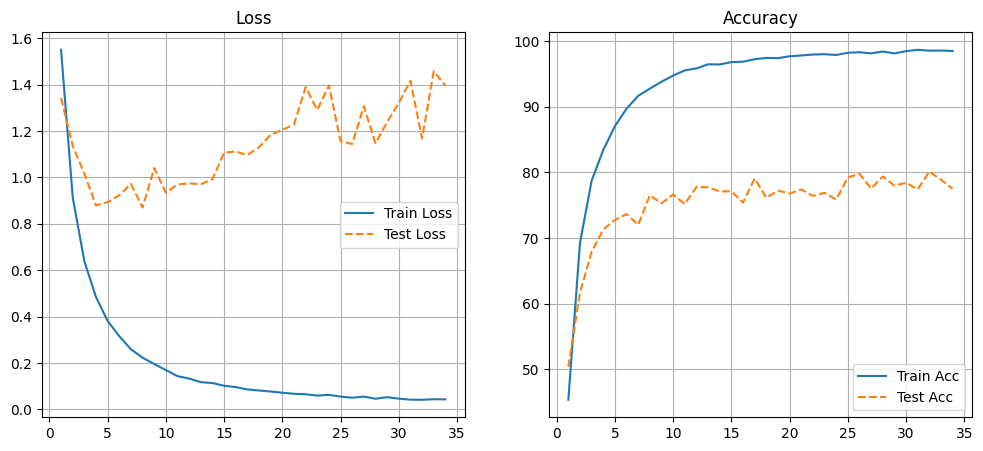

In [ ]:
# ==========================================
# 1. 工具类定义 (EarlyStopping)
# ==========================================
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001):
        """
        Args:
            patience (int): 容忍多少个 epoch loss 不下降
            min_delta (float): 只有 loss 下降超过这个值才被认为是真的改进
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            # 减少打印频率，每10次打印一次，或者只打印早停触发
            if self.counter % 10 == 0:
                print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

# ==========================================
# 2. 网络模块定义
# ==========================================

# --- 特征注意力融合模块 ---
class FeatureAttention(nn.Module):
    def __init__(self, feature_dim):
        super(FeatureAttention, self).__init__()
        self.attn_fc1 = nn.Linear(feature_dim, feature_dim // 4)
        self.attn_fc2 = nn.Linear(feature_dim // 4, feature_dim)
        
    def forward(self, x):
        # x: (Batch_size, Fusion_Dim)
        weights = F.relu(self.attn_fc1(x))
        weights = torch.sigmoid(self.attn_fc2(weights))
        return x * weights

# --- 多尺度 CNN 模块 ---
class MultiScaleCNN(nn.Module):
    def __init__(self, out_channels=64):
        super(MultiScaleCNN, self).__init__()
        
        # 尺度1: 小卷积核 (3x1) - 捕捉高频细节
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度2: 中卷积核 (11x1)
        self.conv2 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度3: 大卷积核 (21x1) - 捕捉低频轮廓
        self.conv3 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=21, padding=10),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 融合层: 输入 16*3=48 -> 输出 out_channels
        self.conv_final = nn.Sequential(
            nn.Conv1d(48, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

    def forward(self, x):
        # x: (Batch, 1, Length)
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)
        
        # 通道拼接
        out = torch.cat([x1, x2, x3], dim=1) 
        out = self.conv_final(out)
        return out

# --- 主模型: CNN-BiLSTM-Fusion V2 ---
class CNN_LSTM_Fusion_Model_V2(nn.Module):
    def __init__(self, manual_feature_dim, num_classes, lstm_hidden_size, dropout_rate): 
        super(CNN_LSTM_Fusion_Model_V2, self).__init__()
        
        # 1. 多尺度 CNN 提取
        self.cnn = MultiScaleCNN(out_channels=64)
        
        # 2. BiLSTM 时序提取
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        self.deep_feature_dim = lstm_hidden_size * 2
        
        # 3. 手动特征投影层 (关键优化: 维度平衡)
        self.manual_projector = nn.Sequential(
            nn.Linear(manual_feature_dim, 128),
            nn.ReLU()
        )
        
        # 4. 融合层定义
        self.fusion_feature_dim = self.deep_feature_dim + 128 # 投影后是 128
        
        # 5. 注意力机制
        self.attention_block = FeatureAttention(self.fusion_feature_dim)
        
        # 6. 分类器
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_feature_dim, 256), 
            nn.ReLU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x_signal, x_manual):
        # x_signal: (B, Length, 1) -> 需要转换为 (B, 1, Length) 给 CNN
        # x_manual: (B, Manual_Dim)
        
        # --- 深度路径 ---
        x = x_signal.permute(0, 2, 1) 
        cnn_out = self.cnn(x) 
        
        # CNN 输出为 (B, C, L_new)，LSTM 需要 (B, L_new, C)
        cnn_out = cnn_out.permute(0, 2, 1) 
        
        _, (h_n, c_n) = self.lstm(cnn_out)
        # 拼接双向 LSTM 的最后状态
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        
        # --- 手动特征路径 ---
        manual_feature_proj = self.manual_projector(x_manual)

        # --- 融合 ---
        fused_feature = torch.cat((deep_feature, manual_feature_proj), dim=1)
        
        # --- 注意力与分类 ---
        weighted_feature = self.attention_block(fused_feature)
        logits = self.fc_classifier(weighted_feature)
        
        return logits

# ==========================================
# 3. 主程序逻辑
# ==========================================
if __name__ == '__main__':
    # 设置随机种子保证复现
    torch.manual_seed(42)
    np.random.seed(42)

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"

    # 1. 加载 NPZ 数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))
    print(f"检测到类别数量: {n_classes}")
    print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

    # 2. 划分数据集 (GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    X_train_raw = X[train_idx]
    y_train_np = y[train_idx]
    X_test_raw = X[test_idx]
    y_test_np = y[test_idx]

    print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
    print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
    print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

    
    # 3. 振动数据归一化
    scaler = MinMaxScaler()
    X_train_flat = X_train_raw.reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)
    
    X_test_flat = X_test_raw.reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

    # 4. 加载并处理手动特征
    print("正在处理手动特征...")
    feature_df = pd.read_csv(feature_csv_path)
    
    # 🔥 严格保留您的写法 'sorce'
    feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
    X_manual_np = feature_df[feature_cols].values 
    print(f"手动特征维度: {X_manual_np.shape}")

    # 按 ID 划分手动特征
    X_manual_train_raw = X_manual_np[train_idx]
    X_manual_test_raw = X_manual_np[test_idx]

    # 手动特征归一化
    manual_scaler = StandardScaler()
    X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)
    X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

    X_manual_train_tensor = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
    X_manual_test_tensor = torch.tensor(X_manual_test_scaled, dtype=torch.float32)

    # 5. 构建 DataLoader
    batch_size = 128
    # Windows 下建议 num_workers=0 以防死锁
    train_dataset = TensorDataset(X_train_tensor, X_manual_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, X_manual_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 6. 初始化模型
    manual_feature_dim = X_manual_train_tensor.shape[1]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 使用您之前的最优参数建议，或者稍微大一点的 hidden_size
    model = CNN_LSTM_Fusion_Model_V2(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=256,   # 之前寻优结果是 256
        dropout_rate=0.5        # 之前寻优结果约 0.5
    ).to(device)

    # 学习率建议设为 0.001 (0.0001 可能太慢)
    optimizer = optim.Adam(model.parameters(), lr=0.001) 
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=30, min_delta=0.01)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    NUM_EPOCHS = 100 

    print(f"开始训练 (V2 模型 - MultiScale + Projector)...")

    # 7. 训练循环
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs_signal, inputs_manual, labels in train_loader:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 梯度剪裁
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs_signal.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total
        
        # --- 验证阶段 ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_running_loss / len(test_loader.dataset)
        epoch_test_acc = 100 * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")
        
        # 早停
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            print("🛑 早停触发！停止训练。")
            model.load_state_dict(early_stopping.best_model_wts)
            break

    # 8. 最终结果
    if not early_stopping.early_stop and early_stopping.best_model_wts:
         model.load_state_dict(early_stopping.best_model_wts)

    print(f"\n✅ 最佳模型最终测试准确率: {early_stopping.best_loss:.4f} (Loss) | 请参考上方 Test Acc")
    
    # 绘图
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', linestyle='--')
    plt.title('Loss')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc')
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', linestyle='--')
    plt.title('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
from tqdm import tqdm
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from optuna.exceptions import TrialPruned
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.01): # Optuna 中降低耐心值
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None # 用于保存最佳模型权重

    # val_loss 必须是 Test Loss
    def __call__(self, val_loss, model): 
        # 只有 loss 下降超过 min_delta 才被认为是真的改进
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            # 仅在实际改进时保存模型权重
            self.best_model_wts = copy.deepcopy(model.state_dict()) 
            self.counter = 0
        else:
            self.counter += 1
            # 仅在达到一定次数或触发早停时打印
            if self.counter % 5 == 0:
                print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}. Best Loss: {self.best_loss:.4f}')
            if self.counter >= self.patience:
                self.early_stop = True
import torch.backends.cudnn as cudnn
if torch.cuda.is_available():
    cudnn.deterministic = True
    cudnn.benchmark = False

# 2. 网络模块定义
# ==========================================

# --- 特征注意力融合模块 ---
class FeatureAttention(nn.Module):
    def __init__(self, feature_dim):
        super(FeatureAttention, self).__init__()
        self.attn_fc1 = nn.Linear(feature_dim, feature_dim // 4)
        self.attn_fc2 = nn.Linear(feature_dim // 4, feature_dim)
        
    def forward(self, x):
        # x: (Batch_size, Fusion_Dim)
        weights = F.relu(self.attn_fc1(x))
        weights = torch.sigmoid(self.attn_fc2(weights))
        return x * weights

# --- 多尺度 CNN 模块 ---
class MultiScaleCNN(nn.Module):
    def __init__(self, out_channels=64):
        super(MultiScaleCNN, self).__init__()
        
        # 尺度1: 小卷积核 (3x1) - 捕捉高频细节
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度2: 中卷积核 (11x1)
        self.conv2 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度3: 大卷积核 (21x1) - 捕捉低频轮廓
        self.conv3 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=21, padding=10),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 融合层: 输入 16*3=48 -> 输出 out_channels
        self.conv_final = nn.Sequential(
            nn.Conv1d(48, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

    def forward(self, x):
        # x: (Batch, 1, Length)
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)
        
        # 通道拼接
        out = torch.cat([x1, x2, x3], dim=1) 
        out = self.conv_final(out)
        return out

# --- 主模型: CNN-BiLSTM-Fusion V2 ---
class CNN_LSTM_Fusion_Model_V2(nn.Module):
    def __init__(self, manual_feature_dim, num_classes, lstm_hidden_size, dropout_rate): 
        super(CNN_LSTM_Fusion_Model_V2, self).__init__()
        
        # 1. 多尺度 CNN 提取
        self.cnn = MultiScaleCNN(out_channels=64)
        
        # 2. BiLSTM 时序提取
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        self.deep_feature_dim = lstm_hidden_size * 2
        
        # 3. 手动特征投影层 (关键优化: 维度平衡)
        self.manual_projector = nn.Sequential(
            nn.Linear(manual_feature_dim, 128),
            nn.ReLU()
        )
        
        # 4. 融合层定义
        self.fusion_feature_dim = self.deep_feature_dim + 128 # 投影后是 128
        
        # 5. 注意力机制
        self.attention_block = FeatureAttention(self.fusion_feature_dim)
        
        # 6. 分类器
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_feature_dim, 256), 
            nn.ReLU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(256, num_classes)
        )

        # 🔥 关键优化: 模型初始化 (提高训练稳定性)
        self._initialize_weights()

    
    def _initialize_weights(self):
        """对所有线性层和 LSTM 参数进行 Kaiming/Xavier 初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.constant_(param.data, 0)

    
    def forward(self, x_signal, x_manual):
        # x_signal: (B, Length, 1) -> 需要转换为 (B, 1, Length) 给 CNN
        # x_manual: (B, Manual_Dim)
        
        # --- 深度路径 ---
        x = x_signal.permute(0, 2, 1) 
        cnn_out = self.cnn(x) 
        
        # CNN 输出为 (B, C, L_new)，LSTM 需要 (B, L_new, C)
        cnn_out = cnn_out.permute(0, 2, 1) 
        
        _, (h_n, c_n) = self.lstm(cnn_out)
        # 拼接双向 LSTM 的最后状态
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        
        # --- 手动特征路径 ---
        manual_feature_proj = self.manual_projector(x_manual)

        # --- 融合 ---
        fused_feature = torch.cat((deep_feature, manual_feature_proj), dim=1)
        
        # --- 注意力与分类 ---
        weighted_feature = self.attention_block(fused_feature)
        logits = self.fc_classifier(weighted_feature)
        
        return logits

# -----------------------------------------------------------
## 3. Optuna Objective 函数 (针对 V2 模型优化)
# -----------------------------------------------------------
def objective(trial, X_train, X_manual_train, y_train, X_test, X_manual_test, y_test, n_classes, manual_feature_dim, device):
    
    # 1. 定义超参数搜索空间 (使用您收紧后的参数)
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True) 
    batch_size = trial.suggest_categorical("batch_size", [64, 128]) # 进一步收紧，先用 64 保证启动
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.45)
    lstm_hidden_size = trial.suggest_categorical("lstm_hidden_size", [128, 256])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    # 2. 模型和数据加载器实例化
    
    train_dataset = TensorDataset(X_train, X_manual_train, y_train)
    test_dataset = TensorDataset(X_test, X_manual_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 🔥 关键修改: 使用 CNN_LSTM_Fusion_Model_V2
    model = CNN_LSTM_Fusion_Model_V2(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=lstm_hidden_size, 
        dropout_rate=dropout_rate 
    ).to(device)

    # 实例化优化器
    if optimizer_name == "Adam":
        # 优化器的参数通常在 Optuna 中寻优，这里不设置权重衰减
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        # AdamW 默认带有权重衰减
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=15, min_delta=0.01) 
    
    # 用于记录该 Trial 的最高准确率
    final_test_acc = 0.0
    MAX_EPOCHS = 60 # Optuna 剪枝的最大 Epoch

    # 3. 训练循环 (新增 tqdm 进度条和梯度裁剪)
    for epoch in range(MAX_EPOCHS): 
        model.train()
        
        # 🔥 关键优化: tqdm 进度条
        train_loop = tqdm(train_loader, desc=f"Trial {trial.number:02d} | E {epoch+1:02d}/{MAX_EPOCHS}", unit="batch")
        
        for inputs_signal, inputs_manual, labels in train_loop:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 🔥 关键优化: 梯度裁剪 (防止 LSTM 梯度爆炸)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
            
            optimizer.step()
            
            # 更新 tqdm 进度条上的 Loss 信息
            train_loop.set_postfix(loss=loss.item())

        # --- 评估阶段 ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_loss / len(test_loader.dataset)
        epoch_test_acc = val_correct / val_total
        
        # 记录该 Trial 历史上的最高准确率
        final_test_acc = max(final_test_acc, epoch_test_acc)
        
        # --- 周期性打印进度 ---
        if (epoch + 1) % 10 == 0 or (epoch + 1) == MAX_EPOCHS:
             print(f"|--- Trial {trial.number:02d} | Epoch {epoch+1:02d}/{MAX_EPOCHS} -> Test Acc: {epoch_test_acc:.4f} | Test Loss: {epoch_test_loss:.4f}")

        # --- Optuna 剪枝和 Early Stopping ---
        trial.report(epoch_test_acc, epoch)
        if trial.should_prune():
            print(f"|--- Trial {trial.number:02d} | ✂️ Optuna Pruner triggered.")
            raise TrialPruned()

        # 早停 (基于 Test Loss)
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            # 打印早停信息，并触发剪枝
            print(f"|--- Trial {trial.number:02d} | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.")
            raise TrialPruned("EarlyStopping triggered by Test Loss.")

    # 返回该 Trial 达到的最高准确率 (用于最大化目标)
    return final_test_acc

## 4. Optuna 寻优启动 (复用您的代码，但修正了参数传递)
# -----------------------------------------------------------
# ... (您的数据加载和划分逻辑) ...
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)
#------------------------------------------
# --- 构建 DataLoader ---
batch_size = 256
train_dataset = TensorDataset(X_train, X_manual_train, y_train)
test_dataset = TensorDataset(X_test, X_manual_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 设定数据库文件的名字 (会在当前目录下生成一个 .db 文件)
db_name = r"E:\故障诊断2\实验整理\code\DBN_FD\optuna_bearing_experiment_v2.db"
storage_name = f"sqlite:///{db_name}"

print(f"🚀 正在连接数据库: {db_name}")

# 🔥 Optuna 启动配置
pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=60, reduction_factor=3) # max_resource 对应 epoch 数量
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize", 
    sampler=sampler, 
    pruner=pruner,
    study_name="CNN_LSTM_Fusion_HPO_v2_3", # 🔥 建议换个名字，区分 V1 模型
    storage=storage_name, 
    load_if_exists=True 
)

print("🚀 开始 Optuna 超参数优化...")

optimization_kwargs = {
    "X_train": X_train, 
    "X_manual_train": X_manual_train, 
    "y_train": y_train,
    "X_test": X_test, 
    "X_manual_test": X_manual_test, 
    "y_test": y_test,
    "n_classes": n_classes,
    "manual_feature_dim": manual_feature_dim,
    "device": device
}

# 设定总共想跑多少次 Trial (比如 50)
study.optimize(
    lambda trial: objective(trial, **optimization_kwargs), 
    n_trials=50 
)

print("\n🎉 寻优完成！")
print(f"最佳准确率: {study.best_value:.4f}")
print("最佳超参数:", study.best_params)


d:\anaconda\envs\pikaqiu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

[I 2025-12-11 11:03:25,943] Using an existing study with name 'CNN_LSTM_Fusion_HPO_v2_3' instead of creating a new one.


🚀 开始 Optuna 超参数优化...


Trial 24 | E 01/60: 100%|██████████| 345/345 [00:42<00:00,  8.11batch/s, loss=1.7] 
Trial 24 | E 02/60: 100%|██████████| 345/345 [00:43<00:00,  7.94batch/s, loss=1.52]
Trial 24 | E 03/60: 100%|██████████| 345/345 [00:41<00:00,  8.41batch/s, loss=1.42]
Trial 24 | E 04/60: 100%|██████████| 345/345 [00:40<00:00,  8.49batch/s, loss=1.25] 
Trial 24 | E 05/60: 100%|██████████| 345/345 [00:40<00:00,  8.46batch/s, loss=1.32] 
Trial 24 | E 06/60: 100%|██████████| 345/345 [00:40<00:00,  8.52batch/s, loss=0.787]
[I 2025-12-11 11:07:59,402] Trial 24 pruned. 


...

   -> EarlyStopping counter: 15 out of 15. Best Loss: 0.8168
|--- Trial 71 | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.


Trial 72 | E 01/60: 100%|██████████| 345/345 [00:54<00:00,  6.34batch/s, loss=1.58]
Trial 72 | E 02/60: 100%|██████████| 345/345 [00:58<00:00,  5.87batch/s, loss=1.48]
Trial 72 | E 03/60: 100%|██████████| 345/345 [01:01<00:00,  5.63batch/s, loss=1.13] 
Trial 72 | E 04/60: 100%|██████████| 345/345 [00:59<00:00,  5.78batch/s, loss=1.08] 
Trial 72 | E 05/60: 100%|██████████| 345/345 [01:00<00:00,  5.66batch/s, loss=0.865]
Trial 72 | E 06/60: 100%|██████████| 345/345 [01:05<00:00,  5.29batch/s, loss=0.999]
[I 2025-12-11 21:01:06,338] Trial 72 pruned. 


|--- Trial 72 | ✂️ Optuna Pruner triggered.


Trial 73 | E 01/60: 100%|██████████| 345/345 [01:05<00:00,  5.29batch/s, loss=1.72]
Trial 73 | E 02/60: 100%|██████████| 345/345 [00:59<00:00,  5.79batch/s, loss=1.43]
Trial 73 | E 03/60: 100%|██████████| 345/345 [01:03<00:00,  5.43batch/s, loss=1.35]
Trial 73 | E 04/60: 100%|██████████| 345/345 [00:54<00:00,  6.37batch/s, loss=1.39] 
Trial 73 | E 05/60: 100%|██████████| 345/345 [00:49<00:00,  7.00batch/s, loss=1.22] 
Trial 73 | E 06/60: 100%|██████████| 345/345 [00:50<00:00,  6.80batch/s, loss=1.24] 
[I 2025-12-11 21:07:17,987] Trial 73 pruned. 


|--- Trial 73 | ✂️ Optuna Pruner triggered.

🎉 寻优完成！
最佳准确率: 0.7932
最佳超参数: {'lr': 5.3592589751554874e-05, 'batch_size': 64, 'dropout_rate': 0.3654958974053892, 'lstm_hidden_size': 256, 'optimizer': 'AdamW'}


# 六、修改特征融合方式
跨模态门控融合（Cross-Modal Gated Fusion）。解决特征分布失衡的问题。
多模态学习的门控单元和注意力鸡翅，克服了简单拼接无法处理深度特征和手动特征之间尺度和语义差异的问题。
引入门控向量，用于动态控制两种特征信息流向的比例。

In [9]:
from tqdm import tqdm
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from optuna.exceptions import TrialPruned
from sklearn.model_selection import GroupShuffleSplit # 👈 关键引入
class EarlyStopping:
    def __init__(self, patience=60, min_delta=0.01): # Optuna 中降低耐心值
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_wts = None # 用于保存最佳模型权重

    # val_loss 必须是 Test Loss
    def __call__(self, val_loss, model): 
        # 只有 loss 下降超过 min_delta 才被认为是真的改进
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            # 仅在实际改进时保存模型权重
            self.best_model_wts = copy.deepcopy(model.state_dict()) 
            self.counter = 0
        else:
            self.counter += 1
            # 仅在达到一定次数或触发早停时打印
            if self.counter % 5 == 0:
                print(f'   -> EarlyStopping counter: {self.counter} out of {self.patience}. Best Loss: {self.best_loss:.4f}')
            if self.counter >= self.patience:
                self.early_stop = True
import torch.backends.cudnn as cudnn
if torch.cuda.is_available():
    cudnn.deterministic = True
    cudnn.benchmark = False
class MultiScaleCNN(nn.Module):
    def __init__(self, out_channels=64):
        super(MultiScaleCNN, self).__init__()
        
        # 尺度1: 小卷积核 (3x1) - 捕捉高频细节
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度2: 中卷积核 (11x1)
        self.conv2 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # 尺度3: 大卷积核 (21x1) - 捕捉低频轮廓
        self.conv3 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=21, padding=10),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 融合层: 输入 16*3=48 -> 输出 out_channels
        self.conv_final = nn.Sequential(
            nn.Conv1d(48, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

    def forward(self, x):
        # x: (Batch, 1, Length)
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)
        
        # 通道拼接
        out = torch.cat([x1, x2, x3], dim=1) 
        out = self.conv_final(out)
        return out
# 引入 LayerNorm 以确保归一化 (适用于特征向量)
class GatedFusionUnit(nn.Module):
    def __init__(self, deep_dim, manual_dim, fusion_out_dim=128):
        super(GatedFusionUnit, self).__init__()
        
        # 1. 维度对齐与归一化
        self.project_deep = nn.Sequential(
            nn.Linear(deep_dim, fusion_out_dim),
            nn.LayerNorm(fusion_out_dim) # 对特征向量进行 LayerNorm
        )
        self.project_manual = nn.Sequential(
            nn.Linear(manual_dim, fusion_out_dim),
            nn.LayerNorm(fusion_out_dim)
        )
        
        # 2. 门控网络 (Gate)
        # 输入是原始的拼接特征，用于计算权重
        self.gate_fc = nn.Sequential(
            nn.Linear(deep_dim + manual_dim, fusion_out_dim),
            nn.Sigmoid() # Sigmoid 激活函数生成 0 到 1 之间的权重
        )
        
        self.fusion_out_dim = fusion_out_dim

    def forward(self, deep_feat, manual_feat):
        
        # --- 维度对齐 (得到两个 H) ---
        H_deep = self.project_deep(deep_feat)
        H_manual = self.project_manual(manual_feat)

        # --- 计算门控 Z ---
        # 拼接原始特征以供门控网络学习交互
        Z_input = torch.cat([deep_feat, manual_feat], dim=1) 
        
        # 生成门控向量 Z
        Z = self.gate_fc(Z_input) 

        # --- 门控融合 (核心逻辑) ---
        # Fused = Z * H_deep + (1 - Z) * H_manual
        F_fused = Z * H_deep + (1 - Z) * H_manual 
        
        # 可以选择再加一个 ReLU 或 LayerNorm
        return F_fused
    
# --- 主模型: CNN-BiLSTM-GatedFusion V3 ---
class CNN_LSTM_Fusion_Model_V3(nn.Module):
    def __init__(self, manual_feature_dim, num_classes, lstm_hidden_size, dropout_rate): 
        super(CNN_LSTM_Fusion_Model_V3, self).__init__()
        
        # 1. 多尺度 CNN 提取 (保持不变)
        self.cnn = MultiScaleCNN(out_channels=64)
        
        # 2. BiLSTM 时序提取 (保持不变)
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        self.deep_feature_dim = lstm_hidden_size * 2
        
        # ⭐ 增强归一化：对深度特征的输出添加 LayerNorm
        self.deep_feature_norm = nn.LayerNorm(self.deep_feature_dim)
        
        # 3. 手动特征投影层 (增加归一化和激活)
        self.manual_projector = nn.Sequential(
            nn.Linear(manual_feature_dim, 128),
            nn.LayerNorm(128), # ⭐ 关键：增加 LayerNorm 稳定特征分布
            nn.ReLU(),
            nn.Dropout(dropout_rate) # 增加 Dropout 抑制过拟合
        )
        
        # 4. 融合机制替换：使用 GatedFusionUnit
        self.fusion_out_dim = 128 # 融合后输出维度设定为 128
        self.fusion_block = GatedFusionUnit(
            deep_dim=self.deep_feature_dim, 
            manual_dim=128, 
            fusion_out_dim=self.fusion_out_dim
        )
        
        # 5. 分类器
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_out_dim, 256), # 输入维度改为融合后的输出维度
            nn.ReLU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(256, num_classes)
        )
        
        # 保持你原有的初始化逻辑
        self._initialize_weights()

    def _initialize_weights(self):
        """对所有线性层和 LSTM 参数进行 Kaiming/Xavier 初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.constant_(param.data, 0)
    def forward(self, x_signal, x_manual):
        # ... (CNN 和 LSTM 提取逻辑保持不变) ...
        x = x_signal.permute(0, 2, 1) 
        cnn_out = self.cnn(x) 
        cnn_out = cnn_out.permute(0, 2, 1) 
        
        _, (h_n, c_n) = self.lstm(cnn_out)
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        
        # ⭐ 归一化深度特征
        deep_feature = self.deep_feature_norm(deep_feature)
        
        # --- 手动特征路径 ---
        manual_feature_proj = self.manual_projector(x_manual)

        # --- 融合替换：使用 GatedFusionUnit ---
        # 输入：归一化后的 Deep Feature 和 Manual Feature
        fused_feature = self.fusion_block(deep_feature, manual_feature_proj)
        
        # --- 分类 ---
        logits = self.fc_classifier(fused_feature)
        
        return logits

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
正在处理手动特

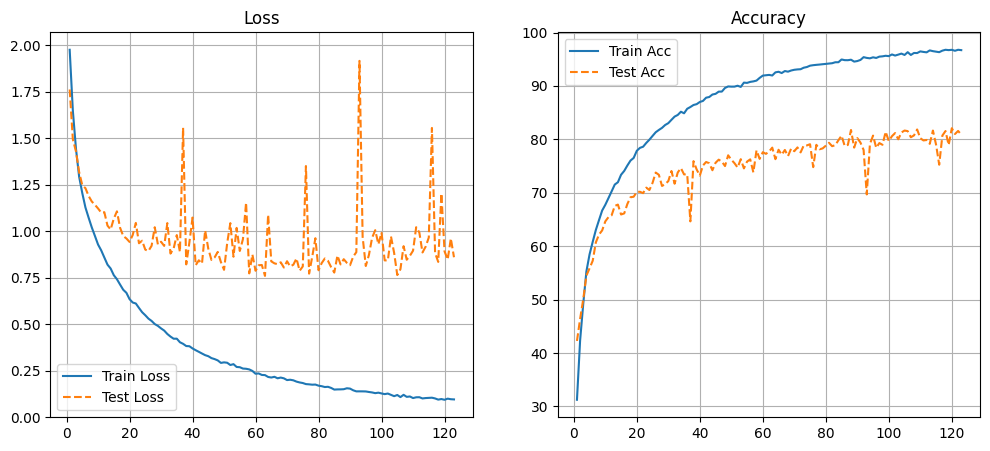

In [11]:
if __name__ == '__main__':
    # 设置随机种子保证复现
    torch.manual_seed(42)
    np.random.seed(42)

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"

    # 1. 加载 NPZ 数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))
    print(f"检测到类别数量: {n_classes}")
    print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

    # 2. 划分数据集 (GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    X_train_raw = X[train_idx]
    y_train_np = y[train_idx]
    X_test_raw = X[test_idx]
    y_test_np = y[test_idx]

    print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
    print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
    print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

    
    # 3. 振动数据归一化
    scaler = MinMaxScaler()
    X_train_flat = X_train_raw.reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)
    
    X_test_flat = X_test_raw.reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

    # 4. 加载并处理手动特征
    print("正在处理手动特征...")
    feature_df = pd.read_csv(feature_csv_path)
    
    # 🔥 严格保留您的写法 'sorce'
    feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
    X_manual_np = feature_df[feature_cols].values 
    print(f"手动特征维度: {X_manual_np.shape}")

    # 按 ID 划分手动特征
    X_manual_train_raw = X_manual_np[train_idx]
    X_manual_test_raw = X_manual_np[test_idx]

    # 手动特征归一化
    manual_scaler = StandardScaler()
    X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)
    X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

    X_manual_train_tensor = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
    X_manual_test_tensor = torch.tensor(X_manual_test_scaled, dtype=torch.float32)

    # 5. 构建 DataLoader
    batch_size = 64
    # Windows 下建议 num_workers=0 以防死锁
    train_dataset = TensorDataset(X_train_tensor, X_manual_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, X_manual_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 6. 初始化模型
    manual_feature_dim = X_manual_train_tensor.shape[1]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 使用您之前的最优参数建议，或者稍微大一点的 hidden_size
    model = CNN_LSTM_Fusion_Model_V3(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=256,   # 之前寻优结果是 256
        dropout_rate=0.35        # 之前寻优结果约 0.5
    ).to(device)

    # 学习率建议设为 0.001 (0.0001 可能太慢)
    optimizer = optim.Adam(model.parameters(), lr=5.3e-5) 
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=60, min_delta=0.01)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    NUM_EPOCHS = 150 

    print(f"开始训练 (V3 模型 - MultiScale + Projector)...")

    # 7. 训练循环
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs_signal, inputs_manual, labels in train_loader:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 梯度剪裁
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs_signal.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total
        
        # --- 验证阶段 ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_running_loss / len(test_loader.dataset)
        epoch_test_acc = 100 * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")
        
        # 早停
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            print("🛑 早停触发！停止训练。")
            model.load_state_dict(early_stopping.best_model_wts)
            break

    # 8. 最终结果
    if not early_stopping.early_stop and early_stopping.best_model_wts:
         model.load_state_dict(early_stopping.best_model_wts)

    print(f"\n✅ 最佳模型最终测试准确率: {early_stopping.best_loss:.4f} (Loss) | 请参考上方 Test Acc")
    
    # 绘图
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', linestyle='--')
    plt.title('Loss')
    plt.legend()
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc')
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', linestyle='--')
    plt.title('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

# 参数寻优

In [ ]:
## 3. Optuna Objective 函数 (针对 V2 模型优化)
# -----------------------------------------------------------
def objective(trial, X_train, X_manual_train, y_train, X_test, X_manual_test, y_test, n_classes, manual_feature_dim, device):
    
    # 1. 定义超参数搜索空间 (收紧后的 V3 空间)
    lr = trial.suggest_float("lr", 2e-5, 2e-4, log=True) # 聚焦在低学习率区域
    batch_size = trial.suggest_categorical("batch_size", [64, 128]) 
    dropout_rate = trial.suggest_float("dropout_rate", 0.25, 0.4)
    lstm_hidden_size = trial.suggest_categorical("lstm_hidden_size", [256, 384]) # 探索更大的隐藏层
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

    # 2. 模型和数据加载器实例化
    
    train_dataset = TensorDataset(X_train, X_manual_train, y_train)
    test_dataset = TensorDataset(X_test, X_manual_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 🔥 关键修改: 使用 CNN_LSTM_Fusion_Model_V3
    model = CNN_LSTM_Fusion_Model_V3(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=lstm_hidden_size, 
        dropout_rate=dropout_rate 
    ).to(device)

    # 实例化优化器
    if optimizer_name == "Adam":
        # 优化器的参数通常在 Optuna 中寻优，这里不设置权重衰减
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        # AdamW 默认带有权重衰减
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=30, min_delta=0.01) 
    
    # 用于记录该 Trial 的最高准确率
    final_test_acc = 0.0
    MAX_EPOCHS = 60 # Optuna 剪枝的最大 Epoch

    # 3. 训练循环 (新增 tqdm 进度条和梯度裁剪)
    for epoch in range(MAX_EPOCHS): 
        model.train()
        
        # 🔥 关键优化: tqdm 进度条
        train_loop = tqdm(train_loader, desc=f"Trial {trial.number:02d} | E {epoch+1:02d}/{MAX_EPOCHS}", unit="batch")
        
        for inputs_signal, inputs_manual, labels in train_loop:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 🔥 关键优化: 梯度裁剪 (防止 LSTM 梯度爆炸)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
            
            optimizer.step()
            
            # 更新 tqdm 进度条上的 Loss 信息
            train_loop.set_postfix(loss=loss.item())

        # --- 评估阶段 ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_loss / len(test_loader.dataset)
        epoch_test_acc = val_correct / val_total
        
        # 记录该 Trial 历史上的最高准确率
        final_test_acc = max(final_test_acc, epoch_test_acc)
        
        # --- 周期性打印进度 ---
        if (epoch + 1) % 10 == 0 or (epoch + 1) == MAX_EPOCHS:
             print(f"|--- Trial {trial.number:02d} | Epoch {epoch+1:02d}/{MAX_EPOCHS} -> Test Acc: {epoch_test_acc:.4f} | Test Loss: {epoch_test_loss:.4f}")

        # --- Optuna 剪枝和 Early Stopping ---
        trial.report(epoch_test_acc, epoch)
        if trial.should_prune():
            print(f"|--- Trial {trial.number:02d} | ✂️ Optuna Pruner triggered.")
            raise TrialPruned()

        # 早停 (基于 Test Loss)
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            # 打印早停信息，并触发剪枝
            print(f"|--- Trial {trial.number:02d} | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.")
            raise TrialPruned("EarlyStopping triggered by Test Loss.")

    # 返回该 Trial 达到的最高准确率 (用于最大化目标)
    return final_test_acc

## 4. Optuna 寻优启动 (复用您的代码，但修正了参数传递)
# -----------------------------------------------------------
# ... (您的数据加载和划分逻辑) ...
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)
#------------------------------------------
# --- 构建 DataLoader ---
# batch_size = 256
# train_dataset = TensorDataset(X_train, X_manual_train, y_train)
# test_dataset = TensorDataset(X_test, X_manual_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 设定数据库文件的名字 (会在当前目录下生成一个 .db 文件)
db_name = r"E:\故障诊断2\实验整理\code\DBN_FD\optuna_bearing_experiment_v2.db"
storage_name = f"sqlite:///{db_name}"

print(f"🚀 正在连接数据库: {db_name}")

# 🔥 Optuna 启动配置
pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=60, reduction_factor=3) # max_resource 对应 epoch 数量
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize", 
    sampler=sampler, 
    pruner=pruner,
    study_name="CNN_LSTM_Fusion_HPO_v3", # 🔥 建议换个名字，区分 V1 模型
    storage=storage_name, 
    load_if_exists=True 
)

print("🚀 开始 Optuna 超参数优化...")

optimization_kwargs = {
    "X_train": X_train, 
    "X_manual_train": X_manual_train, 
    "y_train": y_train,
    "X_test": X_test, 
    "X_manual_test": X_manual_test, 
    "y_test": y_test,
    "n_classes": n_classes,
    "manual_feature_dim": manual_feature_dim,
    "device": device
}

# 设定总共想跑多少次 Trial (比如 50)
study.optimize(
    lambda trial: objective(trial, **optimization_kwargs), 
    n_trials=5
)

print("\n🎉 寻优完成！")
print(f"最佳准确率: {study.best_value:.4f}")
print("最佳超参数:", study.best_params)


正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

[I 2025-12-14 17:05:58,925] Using an existing study with name 'CNN_LSTM_Fusion_HPO_v3' instead of creating a new one.


🚀 开始 Optuna 超参数优化...


Trial 52 | E 01/60: 100%|██████████| 345/345 [00:40<00:00,  8.42batch/s, loss=1.75]
Trial 52 | E 02/60: 100%|██████████| 345/345 [00:40<00:00,  8.54batch/s, loss=1.51]
Trial 52 | E 03/60: 100%|██████████| 345/345 [00:43<00:00,  8.02batch/s, loss=1.26] 
Trial 52 | E 04/60: 100%|██████████| 345/345 [00:43<00:00,  7.95batch/s, loss=1.22] 
Trial 52 | E 05/60: 100%|██████████| 345/345 [00:43<00:00,  7.93batch/s, loss=1.16] 
Trial 52 | E 06/60: 100%|██████████| 345/345 [00:43<00:00,  7.87batch/s, loss=0.975]
Trial 52 | E 07/60: 100%|██████████| 345/345 [00:43<00:00,  7.88batch/s, loss=1.05] 
Trial 52 | E 08/60: 100%|██████████| 345/345 [00:42<00:00,  8.03batch/s, loss=0.948]
Trial 52 | E 09/60: 100%|██████████| 345/345 [00:43<00:00,  7.99batch/s, loss=0.522]
Trial 52 | E 10/60: 100%|██████████| 345/345 [00:43<00:00,  7.97batch/s, loss=0.577]


|--- Trial 52 | Epoch 10/60 -> Test Acc: 0.6878 | Test Loss: 1.0286


...

   -> EarlyStopping counter: 10 out of 30. Best Loss: 0.7540


Trial 61 | E 53/60: 100%|██████████| 173/173 [04:15<00:00,  1.47s/batch, loss=0.125] 
Trial 61 | E 54/60: 100%|██████████| 173/173 [04:15<00:00,  1.48s/batch, loss=0.197] 
Trial 61 | E 55/60: 100%|██████████| 173/173 [04:14<00:00,  1.47s/batch, loss=0.149] 
Trial 61 | E 56/60: 100%|██████████| 173/173 [04:14<00:00,  1.47s/batch, loss=0.115] 
Trial 61 | E 57/60: 100%|██████████| 173/173 [04:14<00:00,  1.47s/batch, loss=0.0623]


   -> EarlyStopping counter: 15 out of 30. Best Loss: 0.7540


Trial 61 | E 58/60: 100%|██████████| 173/173 [04:15<00:00,  1.48s/batch, loss=0.079] 
Trial 61 | E 59/60: 100%|██████████| 173/173 [04:15<00:00,  1.48s/batch, loss=0.122] 
Trial 61 | E 60/60: 100%|██████████| 173/173 [04:15<00:00,  1.48s/batch, loss=0.0515]
[I 2025-12-15 00:59:14,485] Trial 61 finished with value: 0.8333636198437216 and parameters: {'lr': 0.00017133758129803795, 'batch_size': 128, 'dropout_rate': 0.3597514510820857, 'lstm_hidden_size': 384, 'optimizer': 'Adam'}. Best is trial 61 with value: 0.8333636198437216.


|--- Trial 61 | Epoch 60/60 -> Test Acc: 0.6913 | Test Loss: 1.7746

🎉 寻优完成！
最佳准确率: 0.8334
最佳超参数: {'lr': 0.00017133758129803795, 'batch_size': 128, 'dropout_rate': 0.3597514510820857, 'lstm_hidden_size': 384, 'optimizer': 'Adam'}


# v4-添加残差连接

In [12]:
class ResidualConvBlock(nn.Module):
    """一个简单的残差卷积块"""
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super(ResidualConvBlock, self).__init__()
        
        # 主要路径 (即 F(x))
        self.conv_path = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1), # 增加一层卷积进行特征细化
            nn.BatchNorm1d(out_channels),
        )
        
        # 短路连接 (即 x)
        # 仅当输入和输出通道不一致时需要 1x1 卷积进行维度匹配
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
            
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(2)

    def forward(self, x):
        # F(x)
        residual = self.conv_path(x)
        
        # x
        shortcut = self.shortcut(x)
        
        # F(x) + x
        out = self.relu(residual + shortcut)
        
        # 额外增加 MaxPool 降采样
        return self.maxpool(out)
# 替换原来的 MultiScaleCNN
class ResidualMultiScaleCNN(nn.Module):
    def __init__(self, out_channels=64):
        super(ResidualMultiScaleCNN, self).__init__()
        
        # 所有残差块的输入都是 (Batch, 1, Length)，输出通道设定为 32
        channel_base = 32

        # 尺度1: 小卷积核 (3x1)
        self.res_conv1 = ResidualConvBlock(in_channels=1, out_channels=channel_base, kernel_size=3, padding=1)
        
        # 尺度2: 中卷积核 (11x1)
        self.res_conv2 = ResidualConvBlock(in_channels=1, out_channels=channel_base, kernel_size=11, padding=5)
        
        # 尺度3: 大卷积核 (21x1)
        self.res_conv3 = ResidualConvBlock(in_channels=1, out_channels=channel_base, kernel_size=21, padding=10)
        
        # 融合层: 输入 channel_base * 3 = 96 -> 输出 out_channels
        self.conv_final = nn.Sequential(
            nn.Conv1d(channel_base * 3, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 确保 LSTM 输入尺寸不变，out_channels 应与 LSTM input_size 匹配
        self.out_channels = out_channels 

    def forward(self, x):
        # x: (Batch, 1, Length)
        x1 = self.res_conv1(x)
        x2 = self.res_conv2(x)
        x3 = self.res_conv3(x)
        
        # 通道拼接: (B, 32*3, L/8)
        out = torch.cat([x1, x2, x3], dim=1) 
        
        # 最终融合: (B, out_channels, L/16)
        out = self.conv_final(out)
        return out

# 引入 LayerNorm 以确保归一化 (适用于特征向量)
class GatedFusionUnit(nn.Module):
    def __init__(self, deep_dim, manual_dim, fusion_out_dim=128):
        super(GatedFusionUnit, self).__init__()
        
        # 1. 维度对齐与归一化
        self.project_deep = nn.Sequential(
            nn.Linear(deep_dim, fusion_out_dim),
            nn.LayerNorm(fusion_out_dim) # 对特征向量进行 LayerNorm
        )
        self.project_manual = nn.Sequential(
            nn.Linear(manual_dim, fusion_out_dim),
            nn.LayerNorm(fusion_out_dim)
        )
        
        # 2. 门控网络 (Gate)
        # 输入是原始的拼接特征，用于计算权重
        self.gate_fc = nn.Sequential(
            nn.Linear(deep_dim + manual_dim, fusion_out_dim),
            nn.Sigmoid() # Sigmoid 激活函数生成 0 到 1 之间的权重
        )
        
        self.fusion_out_dim = fusion_out_dim

    def forward(self, deep_feat, manual_feat):
        
        # --- 维度对齐 (得到两个 H) ---
        H_deep = self.project_deep(deep_feat)
        H_manual = self.project_manual(manual_feat)

        # --- 计算门控 Z ---
        # 拼接原始特征以供门控网络学习交互
        Z_input = torch.cat([deep_feat, manual_feat], dim=1) 
        
        # 生成门控向量 Z
        Z = self.gate_fc(Z_input) 

        # --- 门控融合 (核心逻辑) ---
        # Fused = Z * H_deep + (1 - Z) * H_manual
        F_fused = Z * H_deep + (1 - Z) * H_manual 
        
        # 可以选择再加一个 ReLU 或 LayerNorm
        return F_fused
    
# --- 主模型: CNN-BiLSTM-GatedFusion V4 ---
class CNN_LSTM_Fusion_Model_V4(nn.Module):
    def __init__(self, manual_feature_dim, num_classes, lstm_hidden_size, dropout_rate): 
        super(CNN_LSTM_Fusion_Model_V4, self).__init__()
        
       # 1. 替换为 残差多尺度 CNN 提取 (主要改进点)
        self.cnn = ResidualMultiScaleCNN(out_channels=64)
        
        # 2. BiLSTM 时序提取 (保持不变)
        self.lstm = nn.LSTM(
            input_size=64, # 需与 ResidualMultiScaleCNN 的 out_channels 匹配
            hidden_size=lstm_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True 
        )
        self.deep_feature_dim = lstm_hidden_size * 2
        self.deep_feature_norm = nn.LayerNorm(self.deep_feature_dim)
        
        # 3. 手动特征投影层 (增加归一化和激活)
        self.manual_projector = nn.Sequential(
            nn.Linear(manual_feature_dim, 128),
            nn.LayerNorm(128), # ⭐ 关键：增加 LayerNorm 稳定特征分布
            nn.ReLU(),
            nn.Dropout(dropout_rate) # 增加 Dropout 抑制过拟合
        )
        
        # 4. 融合机制替换：使用 GatedFusionUnit
        self.fusion_out_dim = 128 # 融合后输出维度设定为 128
        self.fusion_block = GatedFusionUnit(
            deep_dim=self.deep_feature_dim, 
            manual_dim=128, 
            fusion_out_dim=self.fusion_out_dim
        )
        
        # 5. 分类器
        self.fc_classifier = nn.Sequential(
            nn.Linear(self.fusion_out_dim, 256), # 输入维度改为融合后的输出维度
            nn.ReLU(),
            nn.Dropout(dropout_rate), 
            nn.Linear(256, num_classes)
        )
        
        # 保持你原有的初始化逻辑
        self._initialize_weights()

    def _initialize_weights(self):
        """对所有线性层和 LSTM 参数进行 Kaiming/Xavier 初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.constant_(param.data, 0)
    def forward(self, x_signal, x_manual):
        # ... (CNN 和 LSTM 提取逻辑保持不变) ...
        x = x_signal.permute(0, 2, 1) 
        cnn_out = self.cnn(x) 
        cnn_out = cnn_out.permute(0, 2, 1) 
        
        _, (h_n, c_n) = self.lstm(cnn_out)
        deep_feature = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        
        # ⭐ 归一化深度特征
        deep_feature = self.deep_feature_norm(deep_feature)
        
        # --- 手动特征路径 ---
        manual_feature_proj = self.manual_projector(x_manual)

        # --- 融合替换：使用 GatedFusionUnit ---
        # 输入：归一化后的 Deep Feature 和 Manual Feature
        fused_feature = self.fusion_block(deep_feature, manual_feature_proj)
        
        # --- 分类 ---
        logits = self.fc_classifier(fused_feature)
        
        return logits

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
正在处理手动特

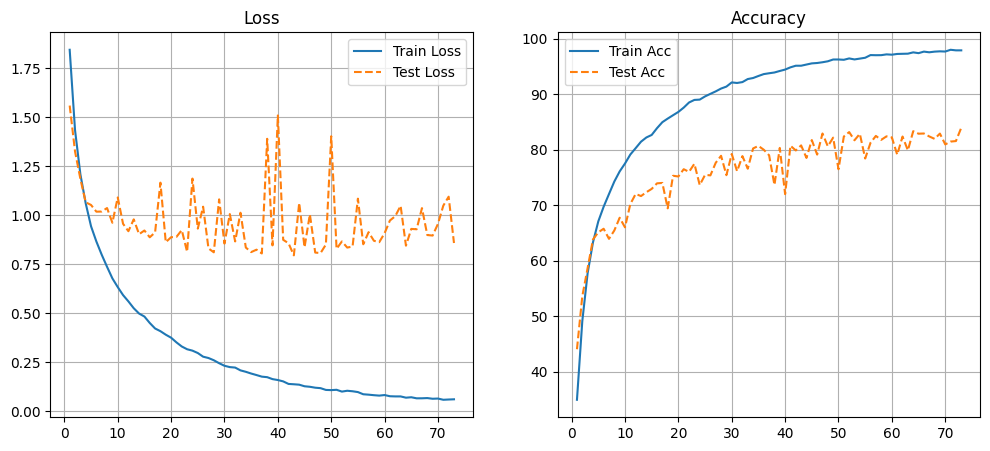

: 

In [ ]:
if __name__ == '__main__':
    # 设置随机种子保证复现
    torch.manual_seed(4)
    np.random.seed(4)

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"

    # 1. 加载 NPZ 数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))
    print(f"检测到类别数量: {n_classes}")
    print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

    # 2. 划分数据集 (GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    X_train_raw = X[train_idx]
    y_train_np = y[train_idx]
    X_test_raw = X[test_idx]
    y_test_np = y[test_idx]

    print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
    print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
    print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

    
    # 3. 振动数据归一化
    scaler = MinMaxScaler()
    X_train_flat = X_train_raw.reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)
    
    X_test_flat = X_test_raw.reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

    # 4. 加载并处理手动特征
    print("正在处理手动特征...")
    feature_df = pd.read_csv(feature_csv_path)
    
    # 🔥 严格保留您的写法 'sorce'
    feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
    X_manual_np = feature_df[feature_cols].values 
    print(f"手动特征维度: {X_manual_np.shape}")

    # 按 ID 划分手动特征
    X_manual_train_raw = X_manual_np[train_idx]
    X_manual_test_raw = X_manual_np[test_idx]

    # 手动特征归一化
    manual_scaler = StandardScaler()
    X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)
    X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

    X_manual_train_tensor = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
    X_manual_test_tensor = torch.tensor(X_manual_test_scaled, dtype=torch.float32)

    # 5. 构建 DataLoader
    batch_size = 64
    # Windows 下建议 num_workers=0 以防死锁
    train_dataset = TensorDataset(X_train_tensor, X_manual_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, X_manual_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 6. 初始化模型
    manual_feature_dim = X_manual_train_tensor.shape[1]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # 使用您之前的最优参数建议，或者稍微大一点的 hidden_size
    model = CNN_LSTM_Fusion_Model_V4(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=512,   # 之前寻优结果是 256
        dropout_rate=0.35        # 之前寻优结果约 0.5
    ).to(device)

    # 学习率建议设为 0.001 (0.0001 可能太慢)
    optimizer = optim.Adam(model.parameters(), lr=0.0001) 
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=30, min_delta=0.01)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    NUM_EPOCHS = 100

    print(f"开始训练 (V4 模型 - Residual MultiScale CNN+ Projector)...")

    # 7. 训练循环
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs_signal, inputs_manual, labels in train_loader:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 梯度剪裁
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            
            running_loss += loss.item() * inputs_signal.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100 * correct / total
        
        # --- 验证阶段 ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_running_loss / len(test_loader.dataset)
        epoch_test_acc = 100 * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")
        
        # 早停
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            print("🛑 早停触发！停止训练。")
            model.load_state_dict(early_stopping.best_model_wts)
            break

    # 8. 最终结果
    if not early_stopping.early_stop and early_stopping.best_model_wts:
         model.load_state_dict(early_stopping.best_model_wts)

    print(f"\n✅ 最佳模型最终测试准确率: {early_stopping.best_loss:.4f} (Loss) | 请参考上方 Test Acc")
    
    # 绘图
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', linestyle='--')
    plt.title('Loss')
    plt.legend()
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc')
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', linestyle='--')
    plt.title('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
## 3. Optuna Objective 函数 (针对 V4 模型优化)
# -----------------------------------------------------------
def objective(trial, X_train, X_manual_train, y_train, X_test, X_manual_test, y_test, n_classes, manual_feature_dim, device):
    
    # 1. 定义超参数搜索空间 (收紧后的 V3 空间)
    # --- 搜索空间定义 (V4 建议) ---
    
    # 1. 学习率 (lr): 聚焦在 V3 最佳值附近 (0.0001 ~ 0.0002)
    lr = trial.suggest_float("lr", 1e-4, 2e-4, log=True) 
    # 2. Batch Size: 保持不变
    batch_size = trial.suggest_categorical("batch_size", [64, 128]) 
    # 3. Dropout Rate: 维持中等到略高的范围
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.45) 
    # 4. LSTM Hidden Size: 略微扩大高容量探索
    # 相比 V3 的 [256, 384]，加入更高容量 512
    lstm_hidden_size = trial.suggest_categorical("lstm_hidden_size", [256, 384, 512]) 
    # 5. Optimizer: 保持 Adam/AdamW
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])


    # 2. 模型和数据加载器实例化
    
    train_dataset = TensorDataset(X_train, X_manual_train, y_train)
    test_dataset = TensorDataset(X_test, X_manual_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 🔥 关键修改: 使用 CNN_LSTM_Fusion_Model_V3
    model = CNN_LSTM_Fusion_Model_V4(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=lstm_hidden_size, 
        dropout_rate=dropout_rate 
    ).to(device)

    # 实例化优化器
    if optimizer_name == "Adam":
        # 优化器的参数通常在 Optuna 中寻优，这里不设置权重衰减
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        # AdamW 默认带有权重衰减
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=30, min_delta=0.01) 
    
    # 用于记录该 Trial 的最高准确率
    final_test_acc = 0.0
    MAX_EPOCHS = 60 # Optuna 剪枝的最大 Epoch

    # 3. 训练循环 (新增 tqdm 进度条和梯度裁剪)
    for epoch in range(MAX_EPOCHS): 
        model.train()
        
        # 🔥 关键优化: tqdm 进度条
        train_loop = tqdm(train_loader, desc=f"Trial {trial.number:02d} | E {epoch+1:02d}/{MAX_EPOCHS}", unit="batch")
        
        for inputs_signal, inputs_manual, labels in train_loop:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 🔥 关键优化: 梯度裁剪 (防止 LSTM 梯度爆炸)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
            
            optimizer.step()
            
            # 更新 tqdm 进度条上的 Loss 信息
            train_loop.set_postfix(loss=loss.item())

        # --- 评估阶段 ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_loss / len(test_loader.dataset)
        epoch_test_acc = val_correct / val_total
        
        # 记录该 Trial 历史上的最高准确率
        final_test_acc = max(final_test_acc, epoch_test_acc)
        
        # --- 周期性打印进度 ---
        if (epoch + 1) % 10 == 0 or (epoch + 1) == MAX_EPOCHS:
             print(f"|--- Trial {trial.number:02d} | Epoch {epoch+1:02d}/{MAX_EPOCHS} -> Test Acc: {epoch_test_acc:.4f} | Test Loss: {epoch_test_loss:.4f}")

        # --- Optuna 剪枝和 Early Stopping ---
        trial.report(epoch_test_acc, epoch)
        if trial.should_prune():
            print(f"|--- Trial {trial.number:02d} | ✂️ Optuna Pruner triggered.")
            raise TrialPruned()

        # 早停 (基于 Test Loss)
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            # 打印早停信息，并触发剪枝
            print(f"|--- Trial {trial.number:02d} | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.")
            raise TrialPruned("EarlyStopping triggered by Test Loss.")

    # 返回该 Trial 达到的最高准确率 (用于最大化目标)
    return final_test_acc

## 4. Optuna 寻优启动 (复用您的代码，但修正了参数传递)
# -----------------------------------------------------------
# ... (您的数据加载和划分逻辑) ...
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)


manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 设定数据库文件的名字 (会在当前目录下生成一个 .db 文件)
db_name = r"E:\故障诊断2\实验整理\code\DBN_FD\optuna_bearing_experiment_v2.db"
storage_name = f"sqlite:///{db_name}"

print(f"🚀 正在连接数据库: {db_name}")

# 🔥 Optuna 启动配置
pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=60, reduction_factor=3) # max_resource 对应 epoch 数量
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize", 
    sampler=sampler, 
    pruner=pruner,
    study_name="CNN_LSTM_Fusion_HPO_v4", # 🔥 建议换个名字，区分 V1 模型
    storage=storage_name, 
    load_if_exists=True 
)

print("🚀 开始 Optuna 超参数优化...")

optimization_kwargs = {
    "X_train": X_train, 
    "X_manual_train": X_manual_train, 
    "y_train": y_train,
    "X_test": X_test, 
    "X_manual_test": X_manual_test, 
    "y_test": y_test,
    "n_classes": n_classes,
    "manual_feature_dim": manual_feature_dim,
    "device": device
}

# 设定总共想跑多少次 Trial (比如 50)
study.optimize(
    lambda trial: objective(trial, **optimization_kwargs), 
    n_trials=1
)

print("\n🎉 寻优完成！")
print(f"最佳准确率: {study.best_value:.4f}")
print("最佳超参数:", study.best_params)


正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

[I 2025-12-15 21:52:45,686] A new study created in RDB with name: CNN_LSTM_Fusion_HPO_v4


🚀 开始 Optuna 超参数优化...


Trial 00 | E 01/60: 100%|██████████| 345/345 [00:49<00:00,  7.01batch/s, loss=1.78]
Trial 00 | E 02/60: 100%|██████████| 345/345 [00:47<00:00,  7.23batch/s, loss=1.36] 
Trial 00 | E 03/60: 100%|██████████| 345/345 [00:46<00:00,  7.40batch/s, loss=1.01] 
Trial 00 | E 04/60: 100%|██████████| 345/345 [00:46<00:00,  7.40batch/s, loss=1.13] 
Trial 00 | E 05/60: 100%|██████████| 345/345 [00:46<00:00,  7.38batch/s, loss=0.718]
Trial 00 | E 06/60: 100%|██████████| 345/345 [00:45<00:00,  7.53batch/s, loss=0.799]
Trial 00 | E 07/60: 100%|██████████| 345/345 [00:46<00:00,  7.49batch/s, loss=0.701]
Trial 00 | E 08/60: 100%|██████████| 345/345 [00:46<00:00,  7.48batch/s, loss=0.564]
Trial 00 | E 09/60: 100%|██████████| 345/345 [00:46<00:00,  7.49batch/s, loss=0.59] 
Trial 00 | E 10/60: 100%|██████████| 345/345 [00:46<00:00,  7.45batch/s, loss=0.639]


|--- Trial 00 | Epoch 10/60 -> Test Acc: 0.7109 | Test Loss: 0.9827


...

Trial 35 | E 17/60: 100%|██████████| 173/173 [11:37<00:00,  4.03s/batch, loss=0.319]
Trial 35 | E 18/60: 100%|██████████| 173/173 [11:34<00:00,  4.01s/batch, loss=0.351]
Trial 35 | E 19/60: 100%|██████████| 173/173 [11:38<00:00,  4.04s/batch, loss=0.227]
Trial 35 | E 20/60: 100%|██████████| 173/173 [11:33<00:00,  4.01s/batch, loss=0.272]


|--- Trial 35 | Epoch 20/60 -> Test Acc: 0.7412 | Test Loss: 1.0786


Trial 35 | E 21/60: 100%|██████████| 173/173 [11:33<00:00,  4.01s/batch, loss=0.219]
Trial 35 | E 22/60: 100%|██████████| 173/173 [11:38<00:00,  4.04s/batch, loss=0.165]
Trial 35 | E 23/60: 100%|██████████| 173/173 [11:35<00:00,  4.02s/batch, loss=0.27] 
Trial 35 | E 24/60: 100%|██████████| 173/173 [11:38<00:00,  4.04s/batch, loss=0.428]
Trial 35 | E 25/60: 100%|██████████| 173/173 [11:38<00:00,  4.04s/batch, loss=0.228]
Trial 35 | E 26/60: 100%|██████████| 173/173 [11:37<00:00,  4.03s/batch, loss=0.182]
Trial 35 | E 27/60: 100%|██████████| 173/173 [11:36<00:00,  4.03s/batch, loss=0.195]
Trial 35 | E 28/60: 100%|██████████| 173/173 [11:35<00:00,  4.02s/batch, loss=0.26] 
Trial 35 | E 29/60: 100%|██████████| 173/173 [11:34<00:00,  4.02s/batch, loss=0.147]
Trial 35 | E 30/60: 100%|██████████| 173/173 [11:34<00:00,  4.01s/batch, loss=0.163] 


|--- Trial 35 | Epoch 30/60 -> Test Acc: 0.7670 | Test Loss: 0.8949
   -> EarlyStopping counter: 5 out of 30. Best Loss: 0.7984


Trial 35 | E 31/60: 100%|██████████| 173/173 [11:36<00:00,  4.03s/batch, loss=0.209] 
Trial 35 | E 32/60: 100%|██████████| 173/173 [11:34<00:00,  4.01s/batch, loss=0.145] 
Trial 35 | E 33/60:  81%|████████  | 140/173 [09:27<02:15,  4.10s/batch, loss=0.173] 

In [6]:
## 3. Optuna Objective 函数 (针对 V4 模型优化)
# -----------------------------------------------------------
def objective(trial, X_train, X_manual_train, y_train, X_test, X_manual_test, y_test, n_classes, manual_feature_dim, device):
    
    # 1. 定义超参数搜索空间 (收紧后的 V3 空间)
    # --- 搜索空间定义 (V4 建议) ---
    
    # 1. 学习率 (lr): 聚焦在 V3 最佳值附近 (0.0001 ~ 0.0002)
    lr = trial.suggest_float("lr", 1e-4, 2e-4, log=True) 
    # 2. Batch Size: 保持不变
    batch_size = trial.suggest_categorical("batch_size", [64, 128]) 
    # 3. Dropout Rate: 维持中等到略高的范围
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.45) 
    # 4. LSTM Hidden Size: 略微扩大高容量探索
    # 相比 V3 的 [256, 384]，加入更高容量 512
    lstm_hidden_size = trial.suggest_categorical("lstm_hidden_size", [256, 384, 512]) 
    # 5. Optimizer: 保持 Adam/AdamW
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])


    # 2. 模型和数据加载器实例化
    
    train_dataset = TensorDataset(X_train, X_manual_train, y_train)
    test_dataset = TensorDataset(X_test, X_manual_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # 🔥 关键修改: 使用 CNN_LSTM_Fusion_Model_V3
    model = CNN_LSTM_Fusion_Model_V4(
        manual_feature_dim=manual_feature_dim, 
        num_classes=n_classes,
        lstm_hidden_size=lstm_hidden_size, 
        dropout_rate=dropout_rate 
    ).to(device)

    # 实例化优化器
    if optimizer_name == "Adam":
        # 优化器的参数通常在 Optuna 中寻优，这里不设置权重衰减
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        # AdamW 默认带有权重衰减
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=30, min_delta=0.01) 
    
    # 用于记录该 Trial 的最高准确率
    final_test_acc = 0.0
    MAX_EPOCHS = 60 # Optuna 剪枝的最大 Epoch

    # 3. 训练循环 (新增 tqdm 进度条和梯度裁剪)
    for epoch in range(MAX_EPOCHS): 
        model.train()
        
        # 🔥 关键优化: tqdm 进度条
        train_loop = tqdm(train_loader, desc=f"Trial {trial.number:02d} | E {epoch+1:02d}/{MAX_EPOCHS}", unit="batch")
        
        for inputs_signal, inputs_manual, labels in train_loop:
            inputs_signal = inputs_signal.to(device)
            inputs_manual = inputs_manual.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs_signal, inputs_manual) 
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 🔥 关键优化: 梯度裁剪 (防止 LSTM 梯度爆炸)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
            
            optimizer.step()
            
            # 更新 tqdm 进度条上的 Loss 信息
            train_loop.set_postfix(loss=loss.item())

        # --- 评估阶段 ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs_signal, inputs_manual, labels in test_loader:
                inputs_signal = inputs_signal.to(device)
                inputs_manual = inputs_manual.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs_signal, inputs_manual)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs_signal.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_test_loss = val_loss / len(test_loader.dataset)
        epoch_test_acc = val_correct / val_total
        
        # 记录该 Trial 历史上的最高准确率
        final_test_acc = max(final_test_acc, epoch_test_acc)
        
        # --- 周期性打印进度 ---
        if (epoch + 1) % 10 == 0 or (epoch + 1) == MAX_EPOCHS:
             print(f"|--- Trial {trial.number:02d} | Epoch {epoch+1:02d}/{MAX_EPOCHS} -> Test Acc: {epoch_test_acc:.4f} | Test Loss: {epoch_test_loss:.4f}")

        # --- Optuna 剪枝和 Early Stopping ---
        trial.report(epoch_test_acc, epoch)
        if trial.should_prune():
            print(f"|--- Trial {trial.number:02d} | ✂️ Optuna Pruner triggered.")
            raise TrialPruned()

        # 早停 (基于 Test Loss)
        early_stopping(epoch_test_loss, model)
        if early_stopping.early_stop:
            # 打印早停信息，并触发剪枝
            print(f"|--- Trial {trial.number:02d} | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.")
            raise TrialPruned("EarlyStopping triggered by Test Loss.")

    # 返回该 Trial 达到的最高准确率 (用于最大化目标)
    return final_test_acc

## 4. Optuna 寻优启动 (复用您的代码，但修正了参数传递)
# -----------------------------------------------------------
# ... (您的数据加载和划分逻辑) ...
print("正在加载数据...")
data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'

# 加载数据，必须确保返回 ids
X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)

n_classes = len(np.unique(y))
print(f"检测到类别数量: {n_classes}")
print(f"原始数据 X: {X.shape}, y: {y.shape}, ids: {ids.shape}")

# --- 🔥 关键步骤：基于 IDs 进行划分 ---
# n_splits=1 表示只划分一次，test_size=0.2 表示 20% 的 IDs 进入测试集
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# gss.split 会返回索引，确保同一组 id 不会被拆分
train_idx, test_idx = next(gss.split(X, y, groups=ids))

# 使用索引提取数据
X_train_raw = X[train_idx]
y_train_np = y[train_idx]
X_test_raw = X[test_idx]
y_test_np = y[test_idx]

print(f"划分完成 -> 训练集样本数: {len(X_train_raw)}, 测试集样本数: {len(X_test_raw)}")
print(f"训练集包含的 IDs: {np.unique(ids[train_idx])}")
print(f"测试集包含的 IDs: {np.unique(ids[test_idx])}")

# 检查测试集是否包含了所有类别 (可选但建议)
if len(np.unique(y_test_np)) < n_classes:
    print("⚠️ 警告：测试集似乎缺少某些故障类别，这可能是因为该类别的所有ID都被分到了训练集。")
    print(f"测试集当前类别: {np.unique(y_test_np)}")

# --- 归一化 (防泄露：只在训练集上 fit) ---
scaler = MinMaxScaler()

# 1. 在训练集上 fit 并 transform
X_train_flat = X_train_raw.reshape(-1, 2048)
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2048, 1)

# 2. 在测试集上仅 transform (使用训练集的统计数据)
X_test_flat = X_test_raw.reshape(-1, 2048)
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2048, 1)

# --- 转换为 Tensor ---
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

#新增手动特征：-----------
# 加载手动提取的特征
feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
feature_df = pd.read_csv(feature_csv_path)

# 假设特征列是除 'label' 和 'source' 之外的所有列
# ⚠️ 必须确保 feature_df 的行顺序与 X, y 的样本顺序一致
# 并且要排除 'label' 和 'source' (或者您自定义的其他非特征列)
feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
X_manual_np = feature_df[feature_cols].values # (N, 40)
print(f"手动特征维度: {X_manual_np.shape}")

# --- 将手动特征按 ID 划分 ---
X_manual_train_raw = X_manual_np[train_idx]
X_manual_test_raw = X_manual_np[test_idx]

# --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
# 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
# 推荐使用 StandardScaler 或 MinMaxScaler
manual_scaler = StandardScaler() 

# 1. 在训练集上 fit 并 transform
X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

# 2. 在测试集上仅 transform 
X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

# --- 转换为 Tensor ---
# 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

# 新增手动特征 Tensor
X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)


manual_feature_dim = X_manual_train.shape[1] # 获取手动特征的维度 (例如 40)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 设定数据库文件的名字 (会在当前目录下生成一个 .db 文件)
db_name = r"E:\故障诊断2\实验整理\code\DBN_FD\optuna_bearing_experiment_v2.db"
storage_name = f"sqlite:///{db_name}"

print(f"🚀 正在连接数据库: {db_name}")

# 🔥 Optuna 启动配置
pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=60, reduction_factor=3) # max_resource 对应 epoch 数量
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize", 
    sampler=sampler, 
    pruner=pruner,
    study_name="CNN_LSTM_Fusion_HPO_v4", # 🔥 建议换个名字，区分 V1 模型
    storage=storage_name, 
    load_if_exists=True 
)

print("🚀 开始 Optuna 超参数优化...")

optimization_kwargs = {
    "X_train": X_train, 
    "X_manual_train": X_manual_train, 
    "y_train": y_train,
    "X_test": X_test, 
    "X_manual_test": X_manual_test, 
    "y_test": y_test,
    "n_classes": n_classes,
    "manual_feature_dim": manual_feature_dim,
    "device": device
}

# 设定总共想跑多少次 Trial (比如 50)
study.optimize(
    lambda trial: objective(trial, **optimization_kwargs), 
    n_trials=2
)

print("\n🎉 寻优完成！")
print(f"最佳准确率: {study.best_value:.4f}")
print("最佳超参数:", study.best_params)


正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
检测到类别数量: 11
原始数据 X: (27583, 2048), y: (27583,), ids: (27583,)
划分完成 -> 训练集样本数: 22080, 测试集样本数: 5503
训练集包含的 IDs: ['X049' 'X050' 'X056' 'X058' 'X059' 'X105' 'X106' 'X107' 'X118' 'X120'
 'X121' 'X130' 'X131' 'X132' 'X144' 'X145' 'X146' 'X147' 'X156' 'X158'
 'X159' 'X169' 'X170' 'X171' 'X186' 'X188' 'X197' 'X198' 'X199' 'X200'
 'X209' 'X210' 'X211' 'X212' 'X222' 'X223' 'X225' 'X235' 'X236' 'X237'
 'X246' 'X247' 'X249' 'X258' 'X259' 'X260' 'X261' 'X270' 'X271' 'X272'
 'X273' 'X274' 'X277' 'X278' 'X279' 'X280' 'X281' 'X282' 'X283' 'X284'
 'X285' 'X286' 'X287' 'X289' 'X290' 'X292' 'X293' 'X294' 'X295' 'X296'
 'X297' 'X298' 'X300' 'X301' 'X305' 'X307' 'X310' 'X311' 'X313' 'X315'
 'X316' 'X317' 'X318']
测试集包含的 IDs: ['X048' 'X057' 'X108' 'X119' 'X133' 'X160' 'X172' 'X185' 'X187' 'X224'
 'X234' 'X248' 'X275' 'X276' 'X288' 'X291' 'X299' 'X302' 'X306' 'X309'
 'X312']
⚠️ 警告：测

[I 2025-12-18 22:49:20,635] Using an existing study with name 'CNN_LSTM_Fusion_HPO_v4' instead of creating a new one.


🚀 开始 Optuna 超参数优化...


Trial 36 | E 01/60: 100%|██████████| 173/173 [00:44<00:00,  3.89batch/s, loss=1.58]
Trial 36 | E 02/60: 100%|██████████| 173/173 [00:44<00:00,  3.86batch/s, loss=1.19]
Trial 36 | E 03/60: 100%|██████████| 173/173 [00:45<00:00,  3.81batch/s, loss=1.17] 
Trial 36 | E 04/60: 100%|██████████| 173/173 [00:45<00:00,  3.81batch/s, loss=1.2]  
Trial 36 | E 05/60: 100%|██████████| 173/173 [00:45<00:00,  3.79batch/s, loss=0.867]
Trial 36 | E 06/60: 100%|██████████| 173/173 [00:45<00:00,  3.78batch/s, loss=1.15] 
[I 2025-12-18 22:54:17,686] Trial 36 pruned. 


|--- Trial 36 | ✂️ Optuna Pruner triggered.


...

   -> EarlyStopping counter: 25 out of 30. Best Loss: 0.8877


Trial 37 | E 40/60: 100%|██████████| 173/173 [00:34<00:00,  5.04batch/s, loss=0.111] 


|--- Trial 37 | Epoch 40/60 -> Test Acc: 0.7892 | Test Loss: 1.0465


Trial 37 | E 41/60: 100%|██████████| 173/173 [00:33<00:00,  5.09batch/s, loss=0.0506]
Trial 37 | E 42/60: 100%|██████████| 173/173 [00:34<00:00,  5.06batch/s, loss=0.0578]
Trial 37 | E 43/60: 100%|██████████| 173/173 [00:34<00:00,  5.03batch/s, loss=0.0375]
Trial 37 | E 44/60: 100%|██████████| 173/173 [00:34<00:00,  5.04batch/s, loss=0.0807]
[I 2025-12-18 23:22:03,391] Trial 37 pruned. EarlyStopping triggered by Test Loss.


   -> EarlyStopping counter: 30 out of 30. Best Loss: 0.8877
|--- Trial 37 | 🛑 EarlyStopping triggered (Test Loss Plateau). Pruning trial.

🎉 寻优完成！
最佳准确率: 0.8237
最佳超参数: {'lr': 0.0001428236049651661, 'batch_size': 64, 'dropout_rate': 0.3518862129753596, 'lstm_hidden_size': 512, 'optimizer': 'Adam'}


In [5]:
# from collections import Counter
# from optuna.trial import TrialState

# # 1. 统计所有试验状态
# all_trial_states = [t.state for t in study.trials]
# state_counts = Counter(all_trial_states)

# print("\n--- Optuna Study 试验状态分布 ---")
# print(f"COMPLETE (成功完成): {state_counts[TrialState.COMPLETE]}")
# print(f"PRUNED (被剪枝): {state_counts[TrialState.PRUNED]}")
# print(f"FAIL (运行失败): {state_counts[TrialState.FAIL]}")
# print(f"其它 (如 WAITING): {len(study.trials) - state_counts[TrialState.COMPLETE] - state_counts[TrialState.PRUNED] - state_counts[TrialState.FAIL]}")
# print("--------------------------------------")

# if state_counts[TrialState.COMPLETE] == 0:
#     print("\n❌ 警告：数据库中没有 **COMPLETE** 状态的试验！")
#     print("Optuna 无法计算 study.best_value。")

In [ ]:
传统DBN+手动提取的特征

改进方向：数据集的设计，分离训练集和测试集。

先把背景铺垫清楚一些，如果解决跨工况的问题，就换载荷。

如果不解决，就混着？应该要跨工况诊断吧。采样频率的信息也要设计下实验。特征组合也要设计下。

后续跑了一个baseline之后，基础结果应该是有优化空间的。在基础上设计注意力机制模块，以及融入cnn-dbn的模块，都看下效果呢.

数据方面的实验：

从数据筛选到特征处理 到模型改变 希望看到效果是逐步提升的

数据集 = 【‘单工况训练-跨工况预测’、‘跨工况训练-跨工况预测’】

训练测试划分 = 【‘分割训练和测试来自不同编号’、‘混着一起’】

特征集 = 【‘时域特征’、‘频域特征’、‘包络时域特征’、‘包络频域特征’、‘时频特征’】

模型集 = 【‘传统机器学习模型’】

创新模型集 = 【‘经典的bdn’】